## 경로 설정 (레포 공통)

이 셀은 레포 어디에서 노트북을 열어도 `data/` 폴더를 자동으로 찾아 **상대경로 기반**으로 경로를 지정한다.
- `data/raw` 원자료 → `data/interim` 중간 자료 → `data/processed` 최종본, 그림·표는 `outputs/`에 저장한다.
- 노트북은 레포 안 어느 위치에서 실행해도 되지만, 레포 폴더 구조(`data/`, `src/`, `outputs/`)를 바꾸지 않아야 한다.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
for _d in (INTERIM, PROCESSED, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("프로젝트 루트 폴더:", ROOT.name)

프로젝트 루트 폴더: BAF-26-2-finance_2


# 병합패널 검증 EDA (긴축기 + 평시 통합)

두 트랙(긴축기 `재무_원자재_병합패널.csv`, 평시 `평시_재무_원자재_병합패널.csv`)의 병합 정확성을
같은 방법(키검증·직접값대조·파생변수재계산·전체재구성·IQR이상치origin대조)으로 각각 확인한다.
원래 두 개의 별도 노트북(긴축기용/평시용)이었으나, 서로 같은 코드를 대상 파일만 바꿔 돌린 것이라
내용 손실 없이 하나로 합쳤다.

## Part A. 긴축기 트랙


In [2]:

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

for f in ["Malgun Gothic", "AppleGothic", "NanumGothic",
          "Pretendard", "Noto Sans CJK KR", "Noto Sans CJK JP"]:
    try:
        mpl.font_manager.findfont(f, fallback_to_default=False)
        mpl.rcParams["font.family"] = f
        break
    except Exception:
        pass
mpl.rcParams["axes.unicode_minus"] = False

def find_file(names):
    candidates = []
    for name in names:
        candidates += [Path(name), Path("/mnt/data") / name]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {names}")

# 이 노트북은 "2. EDA/" 폴더에서 실행하는 것을 기준으로 상대경로를 잡음
BASE = ROOT
p_stab = INTERIM / "ISTANS 안정성" / "안정성_전체통합_1994_2025.csv"
p_prof = INTERIM / "ISTANS 수익성" / "수익성_전체통합_1994_2025.csv"
p_shock = PROCESSED / "원자재_가격충격_패널.csv"
p_merge = PROCESSED / "재무_원자재_병합패널.csv"

for _label, _p in [("안정성", p_stab), ("수익성", p_prof), ("원자재", p_shock), ("병합본", p_merge)]:
    if not _p.exists():
        raise FileNotFoundError(f"{_label} 파일을 못 찾음: {_p.resolve()}")

stab = pd.read_csv(p_stab, encoding="utf-8-sig")
prof = pd.read_csv(p_prof, encoding="utf-8-sig")
shock = pd.read_csv(p_shock, encoding="utf-8-sig")
merged = pd.read_csv(p_merge, encoding="utf-8-sig")

shock = shock.rename(columns={"year":"연도", "industry_code":"업종코드"})

print("안정성:", p_stab, stab.shape)
print("수익성:", p_prof, prof.shape)
print("원자재:", p_shock, shock.shape)
print("병합본:", p_merge, merged.shape)
print("분석기간:", merged["연도"].min(), "~", merged["연도"].max())
print("업종 수:", merged["업종코드"].nunique())
display(merged.head())


안정성: <repo>\data\interim\ISTANS 안정성\안정성_전체통합_1994_2025.csv (1280, 21)
수익성: <repo>\data\interim\ISTANS 수익성\수익성_전체통합_1994_2025.csv (1280, 8)
원자재: <repo>\data\processed\원자재_가격충격_패널.csv (440, 5)
병합본: <repo>\data\processed\재무_원자재_병합패널.csv (240, 16)
분석기간: 2018 ~ 2023
업종 수: 40


,업종코드,업종,연도,자산총계,단기차입,단기사채,차입의존도,ICR,사전노출도(%),Post,사전현금여력(%),Post×사전현금여력,Post×사전노출도,shock_baseline_1111only,shock_extended_1111_1119,diff_1119_effect
0,I3101,의약,2018,52034,3057,0,18.6000,700.1000,6.2397,0,207.2505,0.0000,0.0000,0.4747,0.4749,0.0001
1,I3101,의약,2019,54757,3510,0,22.1000,549.9000,6.2397,0,207.2505,0.0000,0.0000,-0.0568,-0.0573,-0.0006
2,I3101,의약,2020,64703,4163,0,22.3000,"1,277.2000",6.2397,0,207.2505,0.0000,0.0000,-0.7233,-0.7239,-0.0006
3,I3101,의약,2021,73831,4413,0,21.1000,"1,305.0000",6.2397,0,207.2505,0.0000,0.0000,1.0358,1.0379,0.0021
4,I3101,의약,2022,84453,4813,0,17.5000,"1,053.3000",6.2397,1,207.2505,207.2505,6.2397,0.9733,0.9748,0.0015



## 1. 키 구조 검증

병합에서 가장 먼저 볼 것은 분포가 아니라 **키가 정확히 맞았는지**다.

분석기간에 맞춰 원자료 3개를 자른 뒤,
- `업종코드 × 연도` 중복
- 키 개수
- 원자료에만 있는 키
- 병합본에만 있는 키

를 확인한다.


In [3]:

YEAR_MIN, YEAR_MAX = int(merged["연도"].min()), int(merged["연도"].max())
KEY = ["업종코드", "연도"]

stab_p = stab[stab["연도"].between(YEAR_MIN, YEAR_MAX)].copy()
prof_p = prof[prof["연도"].between(YEAR_MIN, YEAR_MAX)].copy()
shock_p = shock[shock["연도"].between(YEAR_MIN, YEAR_MAX)].copy()

def key_summary(name, df):
    return {
        "자료": name,
        "행수": len(df),
        "업종수": df["업종코드"].nunique(),
        "연도수": df["연도"].nunique(),
        "키중복수": int(df.duplicated(KEY).sum()),
        "전체결측수": int(df.isna().sum().sum())
    }

key_table = pd.DataFrame([
    key_summary("안정성", stab_p),
    key_summary("수익성", prof_p),
    key_summary("원자재", shock_p),
    key_summary("병합본", merged)
])
display(key_table)

def anti_join(left, right, on=KEY):
    return (
        left[on].drop_duplicates()
        .merge(right[on].drop_duplicates(), on=on, how="left", indicator=True)
        .query('_merge == "left_only"')
        .drop(columns="_merge")
    )

coverage = []
for name, src in [("안정성", stab_p), ("수익성", prof_p), ("원자재", shock_p)]:
    src_only = anti_join(src, merged)
    merged_only = anti_join(merged, src)
    coverage.append({
        "원자료": name,
        "원자료에만 있는 키": len(src_only),
        "병합본에만 있는 키": len(merged_only)
    })

coverage = pd.DataFrame(coverage)
display(coverage)

all_key_ok = (
    key_table["키중복수"].sum() == 0 and
    coverage[["원자료에만 있는 키","병합본에만 있는 키"]].to_numpy().sum() == 0
)
display(Markdown(
    "**✅ 키 기준 병합 구조 정상:** 모든 `업종코드 × 연도`가 1:1로 대응합니다."
    if all_key_ok else
    "**⚠️ 키 불일치가 있습니다.**"
))


,자료,행수,업종수,연도수,키중복수,전체결측수
0,안정성,240,40,6,0,0
1,수익성,240,40,6,0,0
2,원자재,240,40,6,0,0
3,병합본,240,40,6,0,0


,원자료,원자료에만 있는 키,병합본에만 있는 키
0,안정성,0,0
1,수익성,0,0
2,원자재,0,0


**✅ 키 기준 병합 구조 정상:** 모든 `업종코드 × 연도`가 1:1로 대응합니다.


## 2. 원자료 값 직접 대조

병합본에서 원자료로부터 직접 가져온 변수는 다음처럼 대응된다.

- **안정성:** `업종`, `자산총계`, `단기차입`, `단기사채`, `차입의존도`
- **수익성:** `이자보상비율` → 병합본의 `ICR`
- **원자재:** 세 shock 변수

상관계수가 아니라 **같은 업종·같은 연도의 값 자체가 동일한지** 확인한다.


In [4]:

audit = merged.copy()

audit = audit.merge(
    stab_p[["업종코드","연도","업종","자산총계","단기차입","단기사채","차입의존도"]],
    on=KEY, how="left", validate="one_to_one",
    suffixes=("", "_안정성원자료")
)

audit = audit.merge(
    prof_p[["업종코드","연도","이자보상비율"]],
    on=KEY, how="left", validate="one_to_one"
)

shock_cols = ["shock_baseline_1111only","shock_extended_1111_1119","diff_1119_effect"]
audit = audit.merge(
    shock_p[KEY + shock_cols],
    on=KEY, how="left", validate="one_to_one",
    suffixes=("", "_원자재원자료")
)

checks = []

checks.append({
    "병합 변수":"업종", "원자료":"안정성", "비교 변수":"업종",
    "일치":int((audit["업종"] == audit["업종_안정성원자료"]).sum()),
    "전체":len(audit), "최대 절대차":np.nan
})

for c in ["자산총계","단기차입","단기사채","차입의존도"]:
    d = (audit[c] - audit[f"{c}_안정성원자료"]).abs()
    checks.append({
        "병합 변수":c, "원자료":"안정성", "비교 변수":c,
        "일치":int(np.isclose(audit[c], audit[f"{c}_안정성원자료"], equal_nan=True).sum()),
        "전체":len(audit), "최대 절대차":float(d.max())
    })

d = (audit["ICR"] - audit["이자보상비율"]).abs()
checks.append({
    "병합 변수":"ICR", "원자료":"수익성", "비교 변수":"이자보상비율",
    "일치":int(np.isclose(audit["ICR"], audit["이자보상비율"], equal_nan=True).sum()),
    "전체":len(audit), "최대 절대차":float(d.max())
})

for c in shock_cols:
    d = (audit[c] - audit[f"{c}_원자재원자료"]).abs()
    checks.append({
        "병합 변수":c, "원자료":"원자재", "비교 변수":c,
        "일치":int(np.isclose(audit[c], audit[f"{c}_원자재원자료"], equal_nan=True).sum()),
        "전체":len(audit), "최대 절대차":float(d.max())
    })

value_audit = pd.DataFrame(checks)
value_audit["일치율(%)"] = value_audit["일치"] / value_audit["전체"] * 100
display(value_audit)

bad_direct = value_audit[value_audit["일치"] != value_audit["전체"]]
display(Markdown(
    "**✅ 직접 병합된 모든 변수의 값이 원자료와 100% 일치합니다.**"
    if bad_direct.empty else
    "**⚠️ 직접 병합값 불일치가 발견됐습니다.**"
))
if not bad_direct.empty:
    display(bad_direct)


,병합 변수,원자료,비교 변수,일치,전체,최대 절대차,일치율(%)
0,업종,안정성,업종,240,240,NaN,100.0000
1,자산총계,안정성,자산총계,240,240,0.0000,100.0000
2,단기차입,안정성,단기차입,240,240,0.0000,100.0000
3,단기사채,안정성,단기사채,240,240,0.0000,100.0000
4,차입의존도,안정성,차입의존도,240,240,0.0000,100.0000
5,ICR,수익성,이자보상비율,240,240,0.0000,100.0000
6,shock_baseline_1111only,원자재,shock_baseline_1111only,240,240,0.0000,100.0000
7,shock_extended_1111_1119,원자재,shock_extended_1111_1119,240,240,0.0000,100.0000
8,diff_1119_effect,원자재,diff_1119_effect,240,240,0.0000,100.0000


**✅ 직접 병합된 모든 변수의 값이 원자료와 100% 일치합니다.**


## 3. 파생변수 재계산

현재 파일에서 확인되는 구조를 원자료로 다시 계산한다.

- `사전노출도(%)` = `Post=0` 기간의 `(단기차입 + 단기사채) / 자산총계 × 100` 평균
- `사전현금여력(%)` = `Post=0` 기간의 `유동자산 / 유동부채 × 100` 평균
- `Post` = 단일 시점 이후 1
- 상호작용항 = `Post × 사전값`

※ **Post 시작연도 자체가 연구설계상 맞는지는 병합 오류와 별개**다.


In [5]:

post_by_year = merged.groupby("연도")["Post"].agg(["min","max","mean","nunique"])
display(post_by_year)

post_years = sorted(merged.loc[merged["Post"] == 1, "연도"].unique())
pre_years_all = sorted(merged.loc[merged["Post"] == 0, "연도"].unique())
# 주의: "Post=0인 연도 전부"가 곧 "사전노출도 계산에 쓴 사전기간"은 아니다.
# 확정된 원본 설계(ISTANS_7단계_금리취약성_예비추정.ipynb)는 사전노출도를
# 2018~2020(3개년) 평균으로만 계산했고, 2021년은 회귀에서 Post=0으로 쓰이지만
# 사전노출도 평균 창에서는 제외된 "갭 연도"다. 평시 트랙은 이 갭이 없어서
# (Post=0 연도 전부 = 사전기간) 자동추론이 우연히 맞았을 뿐이다.
pre_years = [y for y in pre_years_all if y <= 2020]
print("(참고) Post=0 전체 연도:", pre_years_all, "-> 실제 사전기간으로 쓸 것:", pre_years)
cutoff = min(post_years) if post_years else None

print("사전기간:", pre_years)
print("Post=1 기간:", post_years)
print("cutoff:", cutoff)

pre_raw = stab[stab["연도"].isin(pre_years)].copy()
pre_raw["노출도_t"] = (pre_raw["단기차입"] + pre_raw["단기사채"]) / pre_raw["자산총계"] * 100
pre_raw["현금여력_t"] = pre_raw["유동자산"] / pre_raw["유동부채"] * 100

pre_calc = (
    pre_raw.groupby("업종코드", as_index=False)
    .agg(
        사전노출도_재계산=("노출도_t","mean"),
        사전현금여력_재계산=("현금여력_t","mean")
    )
)

der = merged.merge(pre_calc, on="업종코드", how="left", validate="many_to_one")
der["Post_재계산"] = (der["연도"] >= cutoff).astype(int)
der["Post×사전노출도_재계산"] = der["Post_재계산"] * der["사전노출도_재계산"]
der["Post×사전현금여력_재계산"] = der["Post_재계산"] * der["사전현금여력_재계산"]

rows = []
pairs = [
    ("사전노출도(%)","사전노출도_재계산"),
    ("사전현금여력(%)","사전현금여력_재계산"),
    ("Post","Post_재계산"),
    ("Post×사전노출도","Post×사전노출도_재계산"),
    ("Post×사전현금여력","Post×사전현금여력_재계산")
]
for a,b in pairs:
    match = np.isclose(der[a], der[b], rtol=1e-12, atol=1e-12, equal_nan=True)
    rows.append([a, int(match.sum()), len(der), (der[a]-der[b]).abs().max()])

derived_checks = pd.DataFrame(rows, columns=["파생변수","일치","전체","최대 절대차"])
derived_checks["일치율(%)"] = derived_checks["일치"]/derived_checks["전체"]*100
display(derived_checks)

all_derived_ok = (derived_checks["일치"] == len(der)).all()
display(Markdown(
    "**✅ 파생변수도 원자료로 재계산한 값과 모두 일치합니다.**"
    if all_derived_ok else
    "**⚠️ 파생변수 중 불일치가 있습니다.**"
))


,min,max,mean,nunique
연도,,,,
2018,0,0,0.0000,1
2019,0,0,0.0000,1
2020,0,0,0.0000,1
2021,0,0,0.0000,1
2022,1,1,1.0000,1
2023,1,1,1.0000,1


(참고) Post=0 전체 연도: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)] -> 실제 사전기간으로 쓸 것: [np.int64(2018), np.int64(2019), np.int64(2020)]
사전기간: [np.int64(2018), np.int64(2019), np.int64(2020)]
Post=1 기간: [np.int64(2022), np.int64(2023)]
cutoff: 2022


,파생변수,일치,전체,최대 절대차,일치율(%)
0,사전노출도(%),240,240,0.0000,100.0000
1,사전현금여력(%),240,240,0.0000,100.0000
2,Post,240,240,0.0000,100.0000
3,Post×사전노출도,240,240,0.0000,100.0000
4,Post×사전현금여력,240,240,0.0000,100.0000


**✅ 파생변수도 원자료로 재계산한 값과 모두 일치합니다.**


## 4. 원자료에서 병합파일 전체 재구성

원자료 3개만 이용해 현재 병합파일과 같은 구조를 다시 만든 뒤 16개 열 전체를 비교한다.


In [6]:

expected = stab_p[["업종코드","업종","연도","자산총계","단기차입","단기사채","차입의존도"]].copy()

expected = expected.merge(
    prof_p[["업종코드","연도","이자보상비율"]],
    on=KEY, how="left", validate="one_to_one"
).rename(columns={"이자보상비율":"ICR"})

expected = expected.merge(
    pre_calc.rename(columns={
        "사전노출도_재계산":"사전노출도(%)",
        "사전현금여력_재계산":"사전현금여력(%)"
    }),
    on="업종코드", how="left", validate="many_to_one"
)

expected["Post"] = (expected["연도"] >= cutoff).astype(int)
expected["Post×사전현금여력"] = expected["Post"] * expected["사전현금여력(%)"]
expected["Post×사전노출도"] = expected["Post"] * expected["사전노출도(%)"]

expected = expected.merge(
    shock_p[KEY + shock_cols],
    on=KEY, how="left", validate="one_to_one"
)

expected = expected[merged.columns].sort_values(KEY).reset_index(drop=True)
actual = merged.sort_values(KEY).reset_index(drop=True)

full_compare = []
for c in actual.columns:
    if pd.api.types.is_numeric_dtype(actual[c]):
        match = np.isclose(actual[c], expected[c], rtol=1e-12, atol=1e-12, equal_nan=True)
        maxdiff = float((actual[c]-expected[c]).abs().max())
    else:
        match = actual[c].eq(expected[c]).to_numpy()
        maxdiff = np.nan
    full_compare.append({
        "변수":c, "일치":int(match.sum()), "전체":len(actual),
        "일치율(%)":match.mean()*100, "최대 절대차":maxdiff
    })

full_compare = pd.DataFrame(full_compare)
display(full_compare)

all_full_ok = (full_compare["일치"] == full_compare["전체"]).all()
display(Markdown(
    "**✅ 현재 병합파일은 원자료에서 동일하게 재구성됩니다.**"
    if all_full_ok else
    "**⚠️ 전체 재구성 비교에서 불일치가 있습니다.**"
))


,변수,일치,전체,일치율(%),최대 절대차
0,업종코드,240,240,100.0000,NaN
1,업종,240,240,100.0000,NaN
2,연도,240,240,100.0000,0.0000
3,자산총계,240,240,100.0000,0.0000
4,단기차입,240,240,100.0000,0.0000
5,단기사채,240,240,100.0000,0.0000
6,차입의존도,240,240,100.0000,0.0000
7,ICR,240,240,100.0000,0.0000
8,사전노출도(%),240,240,100.0000,0.0000
9,Post,240,240,100.0000,0.0000


**✅ 현재 병합파일은 원자료에서 동일하게 재구성됩니다.**


# 5. 변수별·산업별 간단 EDA

병합이 맞더라도 원자료 자체에 특이값은 있을 수 있다.

### 그래프 선택
- `자산총계`, `단기차입`: 규모 차이가 커서 y축을 `symlog`로 본다.
- `차입의존도`, `ICR`, `원자재충격`: 원척도 box plot
- `단기사채`: 0이 많은 희소변수라 0 비율 + 상위값
- `Post` 및 상호작용항은 기계적으로 생성되므로 별도 그래프를 생략


In [7]:

eda_vars = [
    "자산총계","단기차입","단기사채","차입의존도","ICR",
    "사전노출도(%)","사전현금여력(%)",
    "shock_baseline_1111only","shock_extended_1111_1119","diff_1119_effect"
]
display(merged[eda_vars].describe().T)


,count,mean,std,min,25%,50%,75%,max
자산총계,240.0000,"54,245.6708","68,039.4536",826.0000,"8,467.7500","29,389.0000","74,558.7500","347,433.0000"
단기차입,240.0000,"3,967.1125","4,150.8269",19.0000,829.5000,"2,834.5000","5,536.0000","23,612.0000"
단기사채,240.0000,7.1167,24.3419,0.0000,0.0000,0.0000,1.0000,191.0000
차입의존도,240.0000,37.0358,16.7191,0.2000,27.5750,34.6000,45.4750,119.9000
ICR,240.0000,824.7162,"1,629.2070",-963.0000,285.6250,458.8500,738.4500,"13,480.3000"
사전노출도(%),240.0000,9.8755,4.1817,2.1155,6.3929,9.6605,12.4541,21.4399
사전현금여력(%),240.0000,141.7829,28.0365,86.2049,121.8652,144.8451,159.4005,207.2505
shock_baseline_1111only,240.0000,0.6925,3.5537,-23.2588,-0.5011,0.1780,1.3590,27.4404
shock_extended_1111_1119,240.0000,0.6940,3.5577,-23.2590,-0.5033,0.1775,1.4290,27.4410
diff_1119_effect,240.0000,0.0015,0.0625,-0.5059,-0.0011,-0.0001,0.0015,0.6276


<python-env> MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=years, showfliers=True)


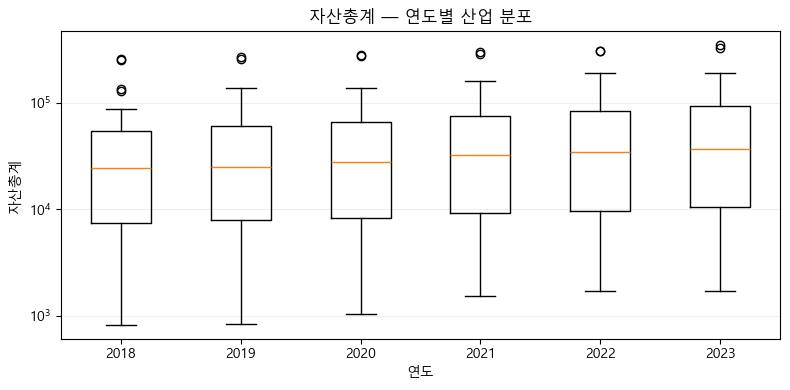

<python-env> MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=years, showfliers=True)


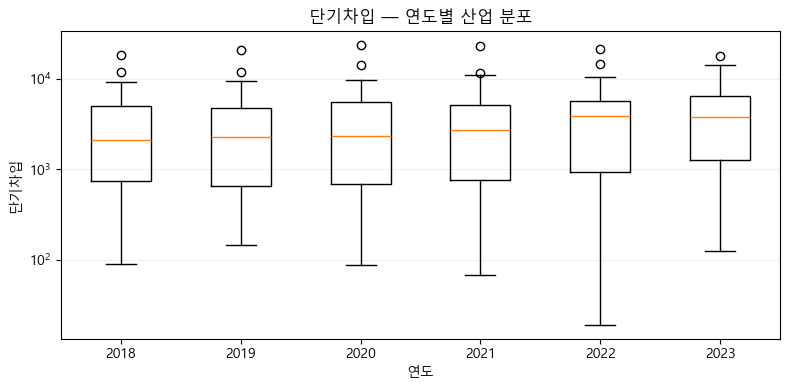

<python-env> MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=years, showfliers=True)


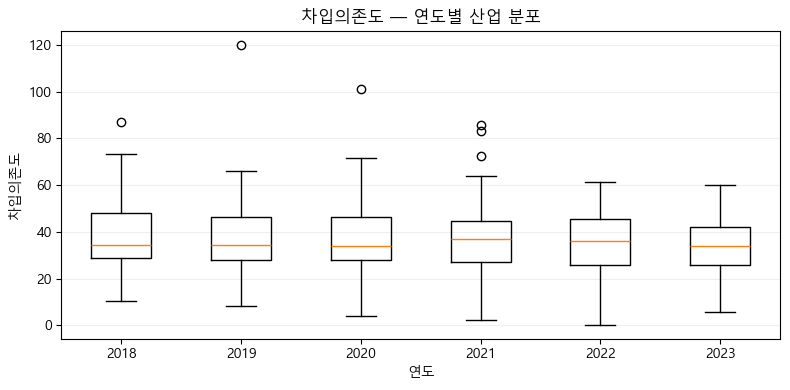

<python-env> MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=years, showfliers=True)
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


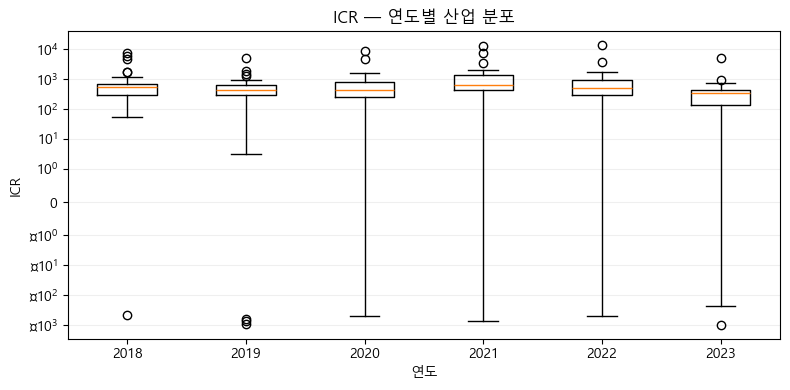

<python-env> MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=years, showfliers=True)


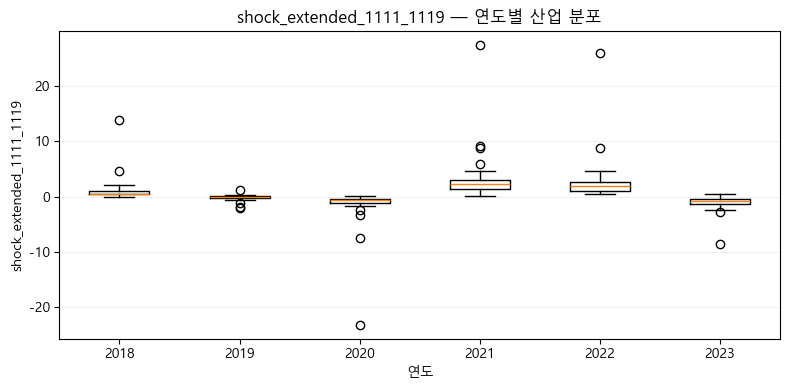

In [8]:

def year_boxplot(var, symlog=False):
    years = sorted(merged["연도"].unique())
    vals = [merged.loc[merged["연도"]==y, var].dropna().to_numpy() for y in years]
    plt.figure(figsize=(8,4))
    plt.boxplot(vals, labels=years, showfliers=True)
    plt.title(f"{var} — 연도별 산업 분포")
    plt.xlabel("연도")
    plt.ylabel(var)
    if symlog:
        plt.yscale("symlog", linthresh=1)
    plt.grid(axis="y", alpha=.2)
    plt.tight_layout()
    plt.show()

for v in ["자산총계","단기차입","차입의존도","ICR","shock_extended_1111_1119"]:
    year_boxplot(v, symlog=(v in ["자산총계","단기차입","ICR"]))



### 단기사채: 0 비율과 상위값

0이 많은 변수는 일반적인 IQR box plot이 지나치게 민감할 수 있어 따로 본다.


,관측수,영인개수,비영개수,0비율(%)
연도,,,,
2018,40,29,11,72.5000
2019,40,27,13,67.5000
2020,40,28,12,70.0000
2021,40,30,10,75.0000
2022,40,28,12,70.0000
2023,40,28,12,70.0000


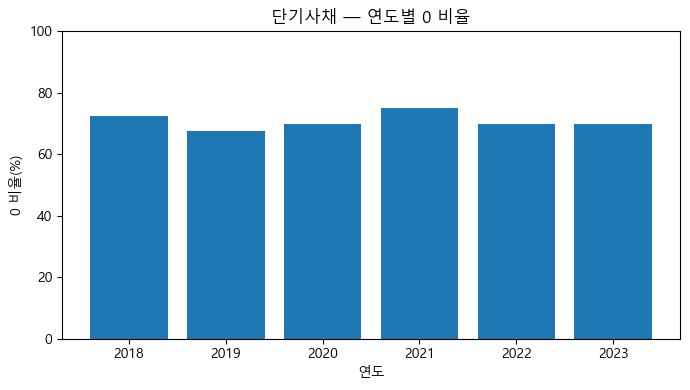

,업종코드,업종,연도,단기사채
70,I3203,기타 전자부품,2022,191
143,I3306,시멘트,2023,185
94,I3207,자동차,2022,127
95,I3207,자동차,2023,115
142,I3306,시멘트,2022,100
90,I3207,자동차,2018,86
93,I3207,자동차,2021,84
130,I3304,유리,2022,80
138,I3306,시멘트,2018,77
67,I3203,기타 전자부품,2019,53


In [9]:

bond_zero = (
    merged.groupby("연도")["단기사채"]
    .agg(관측수="size", 영인개수=lambda s:(s==0).sum(), 비영개수=lambda s:(s!=0).sum())
)
bond_zero["0비율(%)"] = bond_zero["영인개수"]/bond_zero["관측수"]*100
display(bond_zero)

plt.figure(figsize=(7,4))
plt.bar(bond_zero.index.astype(str), bond_zero["0비율(%)"])
plt.ylim(0,100)
plt.title("단기사채 — 연도별 0 비율")
plt.xlabel("연도")
plt.ylabel("0 비율(%)")
plt.tight_layout()
plt.show()

display(
    merged.loc[merged["단기사채"]>0, ["업종코드","업종","연도","단기사채"]]
    .sort_values("단기사채", ascending=False)
    .head(20)
)



## 6. 산업×연도 heatmap

연도별 중앙값과 MAD를 이용해 상대적 특이도를 표시한다.

- 행을 따라 한 연도만 갑자기 튀는 산업
- 모든 연도에서 지속적으로 높은 산업

을 빠르게 찾는 용도다.


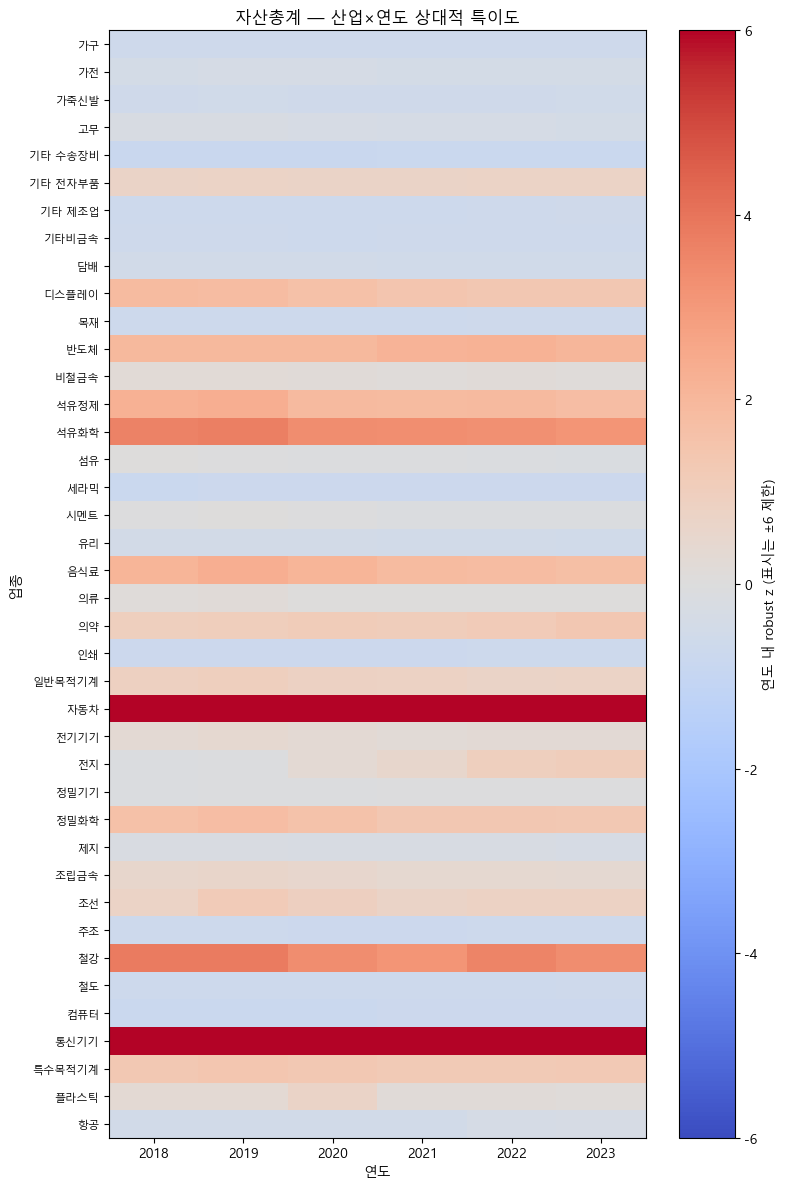

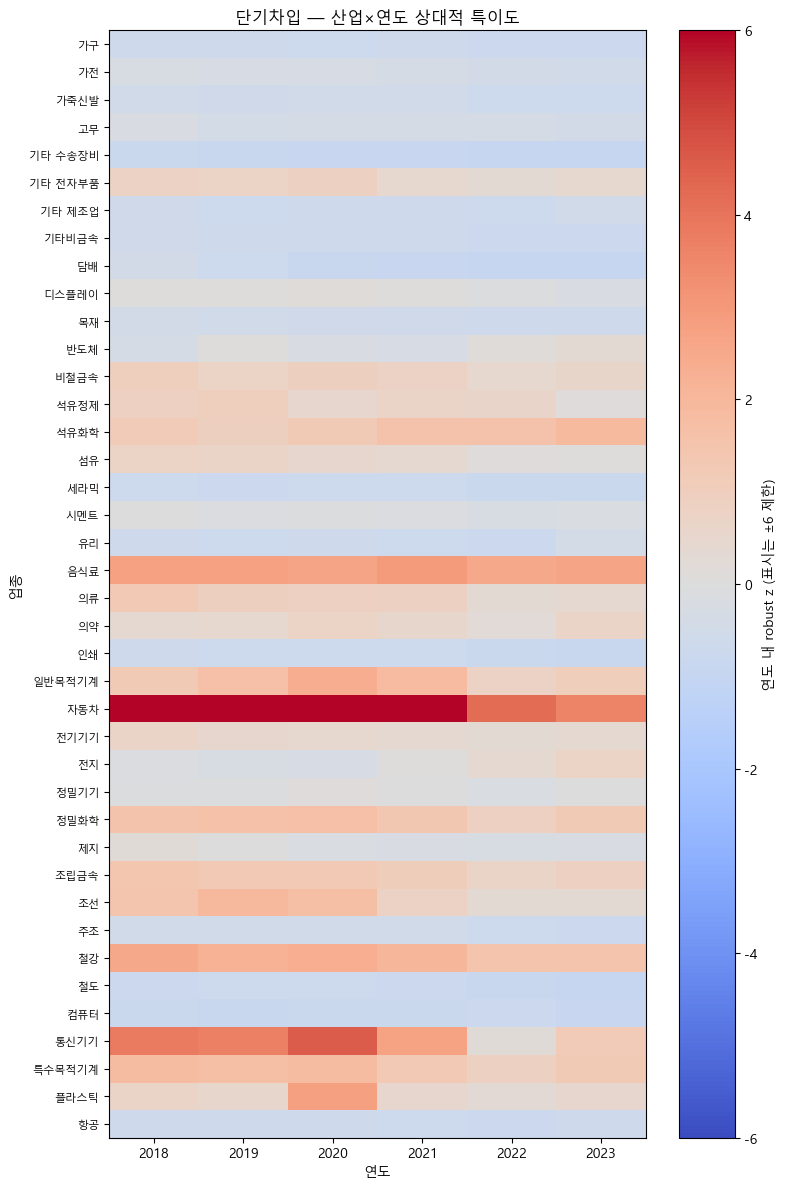

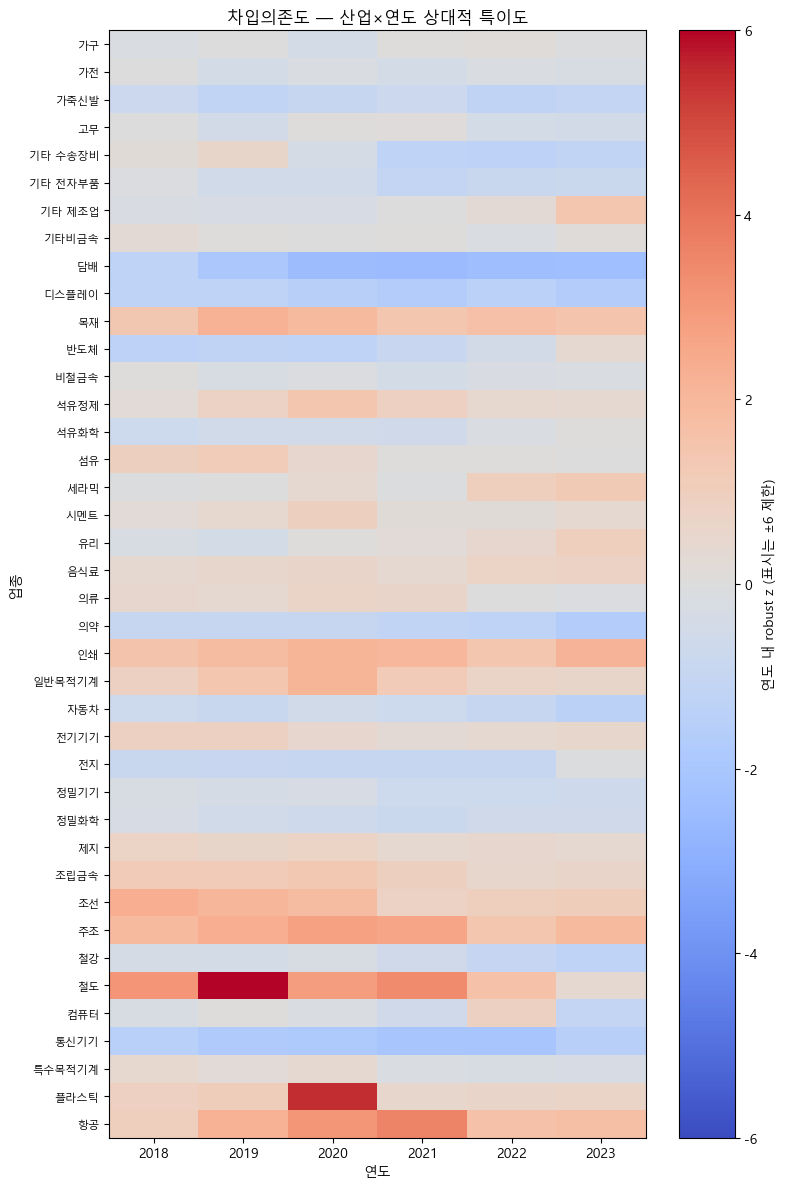

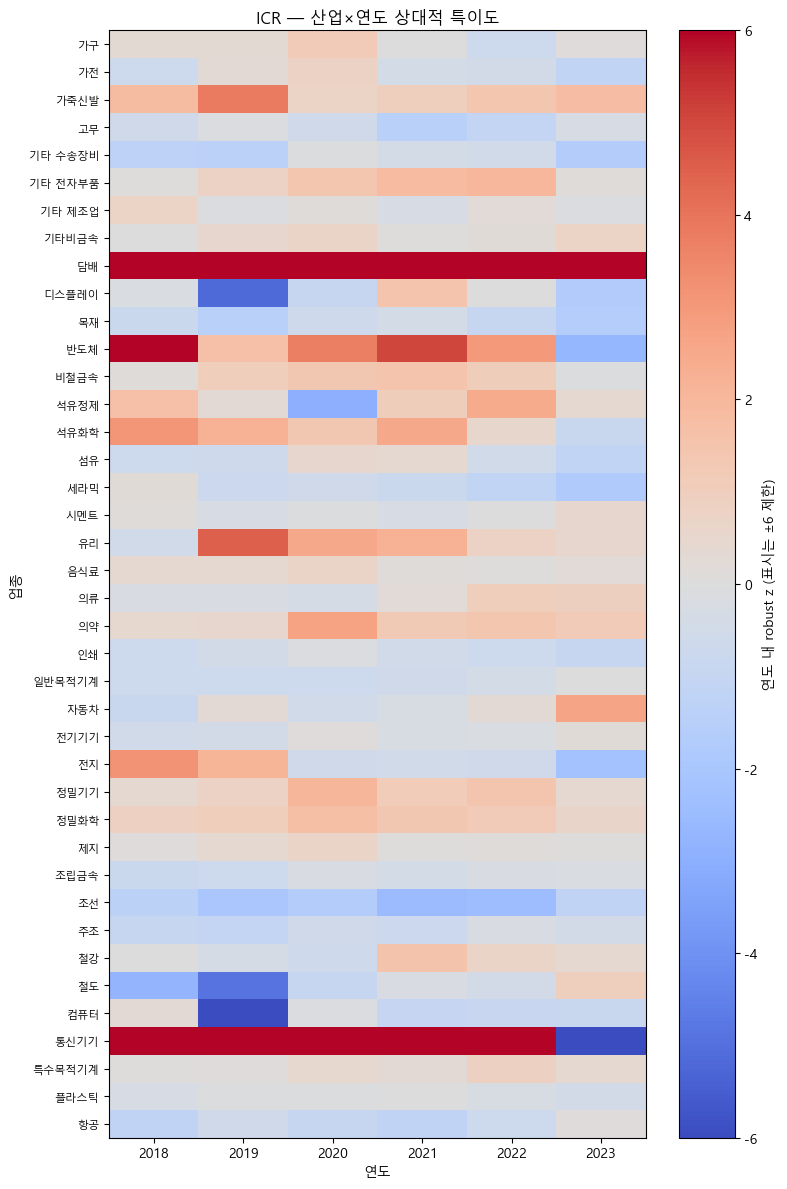

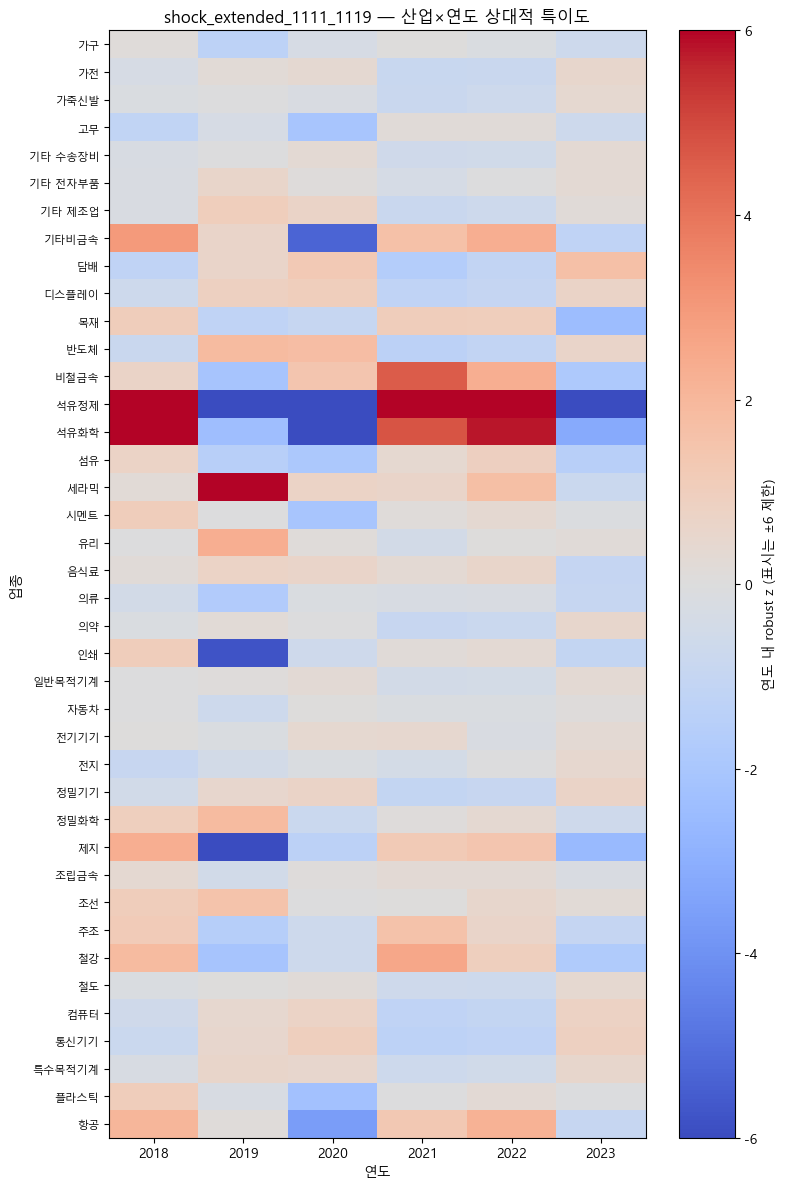

In [10]:

def industry_heatmap(var):
    p = merged.pivot(index="업종", columns="연도", values=var)
    z = p.copy().astype(float)

    for y in z.columns:
        s = z[y]
        med = s.median()
        mad = (s-med).abs().median()
        z[y] = (s-med)/(1.4826*mad) if mad > 0 else 0.0

    arr = np.clip(z.to_numpy(), -6, 6)

    plt.figure(figsize=(8,12))
    im = plt.imshow(arr, aspect="auto", interpolation="nearest",
                    cmap="coolwarm", vmin=-6, vmax=6)
    plt.colorbar(im, label="연도 내 robust z (표시는 ±6 제한)")
    plt.yticks(range(len(z.index)), z.index, fontsize=8)
    plt.xticks(range(len(z.columns)), z.columns)
    plt.title(f"{var} — 산업×연도 상대적 특이도")
    plt.xlabel("연도")
    plt.ylabel("업종")
    plt.tight_layout()
    plt.show()

for v in ["자산총계","단기차입","차입의존도","ICR","shock_extended_1111_1119"]:
    industry_heatmap(v)


### 산업×연도 Heatmap 해석

각 연도별로 40개 산업의 값을 중앙값과 MAD(Median Absolute Deviation)를 이용해 robust z-score로 변환하였다.  
따라서 색상은 변수의 절대적인 크기가 아니라 **같은 연도의 다른 산업과 비교했을 때 상대적으로 높은지 또는 낮은지**를 나타낸다.

- 붉은색: 해당 연도 산업 중앙값보다 상대적으로 높은 값
- 푸른색: 해당 연도 산업 중앙값보다 상대적으로 낮은 값
- 회색에 가까운 색: 해당 연도의 산업 중앙 수준과 비슷한 값
- 색이 진할수록 다른 산업과의 상대적인 차이가 큼

주의할 점은 붉은색이 반드시 좋은 값 또는 양수이고, 푸른색이 나쁜 값 또는 음수라는 의미는 아니라는 것이다. 또한 연도별로 다시 표준화했기 때문에 서로 다른 연도의 색상 크기를 절대값처럼 직접 비교할 수 없다.

#### 자산총계

자동차, 통신기기, 철강, 석유화학 등 일부 산업은 분석기간 동안 지속적으로 다른 산업보다 높은 자산규모를 보인다. 반대로 일부 산업은 지속적으로 상대적으로 작은 자산규모를 나타낸다.

대부분의 산업에서 연도별 상대적 위치가 크게 변하지 않아, 특정 산업의 특정 연도 값이 갑자기 비정상적으로 변한 패턴은 두드러지지 않는다. 따라서 현재 heatmap에서는 병합 과정에서 발생한 뚜렷한 단년도 오류 징후는 확인되지 않았다.

다만 자산총계는 산업 규모의 영향을 크게 받는 변수이므로, 특정 산업 내에서 값이 갑자기 변했는지를 확인하기 위해서는 전년 대비 증감률을 추가로 확인하는 것이 더 적절하다.

#### 단기차입

단기차입에서도 자동차, 통신기기, 철강 등 일부 산업이 지속적으로 높은 상대적 수준을 보인다. 자산총계와 유사한 산업별 규모 차이가 나타나지만, 두 변수의 패턴이 완전히 동일하지는 않는다.

대부분의 산업은 상대적 위치가 안정적이지만, 일반목적기계(2020~2021에만 일시적으로 높아짐)·플라스틱(2020에만 튐)처럼 짧게 튀었다가 돌아오는 예외가 일부 있다. 이런 국소적 변화도 원자료와 직접 대조한 결과 병합파일과 동일했으므로(위 IQR 검토 참고), 병합 과정에서 발생한 오류로 보이지는 않는다.

단기차입 역시 절대금액은 산업 규모의 영향을 받으므로, 이후 분석에서는 차입의존도와 함께 확인할 필요가 있다.

#### ICR

ICR은 자산총계나 단기차입보다 산업별·연도별 변화가 크게 나타난다. 담배는 분석기간(2018~2023) 내내 예외 없이 상대적으로 높은 ICR을 유지한다.

반면 **통신기기와 반도체는 "분석기간 내내 높다"고 볼 수 없다** — 2018~2022년에는 상대적으로 높은(붉은) 위치를 유지하다가, **2023년에만 두 업종 모두 가장 낮은(진한 파랑) 위치로 뒤집힌다.** 이는 우연이 아니라, 앞서 확인된 2022~23년 반도체 업황 다운턴이 실제로 이 시점의 ICR에 반영된 것으로 해석할 수 있다. 디스플레이와 컴퓨터 역시 특정 연도(주로 2019)에 상대적 위치가 크게 바뀐다.

이는 ICR이 산업 규모보다는 영업이익과 이자비용의 변화에 민감한 변수이기 때문에 나타날 수 있는 패턴이다.

특히 한 산업의 색상이 연도에 따라 크게 변하는 경우 실제 값을 추가로 확인할 필요가 있다. 다만 해당 관측값들은 원자료와 직접 대조한 결과 병합파일과 동일하게 나타났으므로, 현재 관찰되는 큰 변화는 병합 과정에서 발생한 오류라기보다 원자료 자체의 산업별 실적 변동으로 볼 수 있다.

#### 원자재 가격충격

원자재 가격충격은 산업과 연도에 따라 상대적 위치가 크게 변화한다. 특히 석유정제와 석유화학 등에서는 연도별 색상 변화가 크게 나타나며, 철강·비철금속 등에서도 비교적 큰 변화가 확인된다.

이는 원자재 가격충격이 단순한 산업별 고정 특성이 아니라 **연도별 원자재 가격 변화와 산업별 원자재 노출구조가 함께 반영된 변수**이기 때문에 나타나는 패턴으로 해석할 수 있다.

따라서 같은 연도에도 산업별 충격 수준에 차이가 존재하며, 이후 패널분석에서 활용할 수 있는 산업×연도 변동이 존재함을 확인할 수 있다.

### 종합

자산총계와 단기차입은 분석기간 동안 산업별 상대적 위치가 비교적 안정적으로 유지되는 반면, ICR과 원자재 가격충격은 산업 및 연도에 따라 상대적 위치 변화가 더 크게 나타났다.

Heatmap에서 일부 특이한 산업×연도 조합이 확인되었으나, 해당 값들을 원자료와 대조한 결과 병합파일과 동일하게 나타났다. 따라서 현재 확인된 특이 패턴은 병합 과정에서 발생한 오류라기보다 원자료 자체의 산업별·연도별 이질성에 따른 것으로 판단하였다.


## 7. IQR 기준 검토 대상

연도별 `Q1 - 1.5×IQR`, `Q3 + 1.5×IQR` 밖의 값을 추린다.

**주의:** 이 표는 오류 목록이 아니다.  
산업자료에서는 실제 산업구조 때문에 큰 값이 자연스럽게 존재할 수 있다.

같은 셀의 원자료 값도 함께 붙여서,
- `원자료일치=True` → 병합 오류가 아니라 원자료부터 존재한 특이값
- `False` → 병합 과정 확인 필요

로 해석한다.


In [11]:

source_map = {
    "자산총계":("안정성", "자산총계_안정성원자료"),
    "단기차입":("안정성", "단기차입_안정성원자료"),
    "차입의존도":("안정성", "차입의존도_안정성원자료"),
    "ICR":("수익성", "이자보상비율"),
    "shock_extended_1111_1119":("원자재", "shock_extended_1111_1119_원자재원자료")
}

def iqr_review_table(var):
    out = []
    for y, g in audit.groupby("연도"):
        s = g[var].dropna()
        q1, q3 = s.quantile([.25,.75])
        iqr = q3-q1
        lo, hi = q1-1.5*iqr, q3+1.5*iqr
        f = g[(g[var] < lo) | (g[var] > hi)].copy()
        if len(f):
            src_name, src_col = source_map[var]
            f["원자료"] = src_name
            f["원자료값"] = f[src_col]
            f["원자료일치"] = np.isclose(f[var], f[src_col], equal_nan=True)
            f["하한"] = lo
            f["상한"] = hi
            out.append(f[["업종코드","업종","연도",var,"원자료","원자료값","원자료일치","하한","상한"]])
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

flag_summary = []
flag_tables = {}

for v in source_map:
    f = iqr_review_table(v)
    flag_tables[v] = f
    flag_summary.append({
        "변수":v,
        "검토대상 수":len(f),
        "그중 원자료 불일치":int((~f["원자료일치"]).sum()) if len(f) else 0
    })

flag_summary = pd.DataFrame(flag_summary)
display(flag_summary)

for v, f in flag_tables.items():
    display(Markdown(f"### {v}"))
    if len(f):
        display(f.sort_values(v).head(10))
        if len(f) > 10:
            display(Markdown("**큰 값 쪽**"))
            display(f.sort_values(v, ascending=False).head(10))
    else:
        print("IQR fence 밖 관측치 없음")


,변수,검토대상 수,그중 원자료 불일치
0,자산총계,14,0
1,단기차입,11,0
2,차입의존도,6,0
3,ICR,23,0
4,shock_extended_1111_1119,18,0


### 자산총계

,업종코드,업종,연도,자산총계,원자료,원자료값,원자료일치,하한,상한
1,I3201,석유화학,2018,128508,안정성,"128,508.0000",True,"-63,236.1250","125,180.8750"
3,I3308,철강,2018,134217,안정성,"134,217.0000",True,"-63,236.1250","125,180.8750"
2,I3207,자동차,2018,251229,안정성,"251,229.0000",True,"-63,236.1250","125,180.8750"
4,I3105,통신기기,2019,257766,안정성,"257,766.0000",True,"-71,481.2500","140,294.7500"
0,I3105,통신기기,2018,259692,안정성,"259,692.0000",True,"-63,236.1250","125,180.8750"
5,I3207,자동차,2019,267160,안정성,"267,160.0000",True,"-71,481.2500","140,294.7500"
6,I3105,통신기기,2020,274060,안정성,"274,060.0000",True,"-78,129.2500","152,436.7500"
7,I3207,자동차,2020,279518,안정성,"279,518.0000",True,"-78,129.2500","152,436.7500"
9,I3207,자동차,2021,290586,안정성,"290,586.0000",True,"-89,621.2500","173,988.7500"
8,I3105,통신기기,2021,298080,안정성,"298,080.0000",True,"-89,621.2500","173,988.7500"


**큰 값 쪽**

,업종코드,업종,연도,자산총계,원자료,원자료값,원자료일치,하한,상한
12,I3105,통신기기,2023,347433,안정성,"347,433.0000",True,"-115,305.8750","220,427.1250"
13,I3207,자동차,2023,325397,안정성,"325,397.0000",True,"-115,305.8750","220,427.1250"
10,I3105,통신기기,2022,307366,안정성,"307,366.0000",True,"-103,261.1250","197,705.8750"
11,I3207,자동차,2022,306695,안정성,"306,695.0000",True,"-103,261.1250","197,705.8750"
8,I3105,통신기기,2021,298080,안정성,"298,080.0000",True,"-89,621.2500","173,988.7500"
9,I3207,자동차,2021,290586,안정성,"290,586.0000",True,"-89,621.2500","173,988.7500"
7,I3207,자동차,2020,279518,안정성,"279,518.0000",True,"-78,129.2500","152,436.7500"
6,I3105,통신기기,2020,274060,안정성,"274,060.0000",True,"-78,129.2500","152,436.7500"
5,I3207,자동차,2019,267160,안정성,"267,160.0000",True,"-71,481.2500","140,294.7500"
0,I3105,통신기기,2018,259692,안정성,"259,692.0000",True,"-63,236.1250","125,180.8750"


...

,업종코드,업종,연도,ICR,원자료,원자료값,원자료일치,하한,상한
19,I3402,담배,2022,"13,480.3000",수익성,"13,480.3000",True,-627.9875,"1,833.1125"
17,I3402,담배,2021,"12,961.3000",수익성,"12,961.3000",True,-925.7625,"2,680.1375"
14,I3402,담배,2020,"8,644.4000",수익성,"8,644.4000",True,-594.3625,"1,643.7375"
0,I3102,반도체,2018,"7,729.6000",수익성,"7,729.6000",True,-284.8750,"1,252.9250"
16,I3105,통신기기,2021,"7,235.4000",수익성,"7,235.4000",True,-925.7625,"2,680.1375"
1,I3105,통신기기,2018,"5,772.6000",수익성,"5,772.6000",True,-284.8750,"1,252.9250"
11,I3402,담배,2019,"5,129.9000",수익성,"5,129.9000",True,-163.6250,"1,078.5750"
22,I3402,담배,2023,"4,957.5000",수익성,"4,957.5000",True,-321.2625,908.0375
13,I3105,통신기기,2020,"4,643.6000",수익성,"4,643.6000",True,-594.3625,"1,643.7375"
5,I3402,담배,2018,"4,642.9000",수익성,"4,642.9000",True,-284.8750,"1,252.9250"


### shock_extended_1111_1119

,업종코드,업종,연도,shock_extended_1111_1119,원자료,원자료값,원자료일치,하한,상한
8,I3301,석유정제,2020,-23.2590,원자재,-23.2590,True,-2.0747,0.5196
17,I3301,석유정제,2023,-8.5872,원자재,-8.5872,True,-2.8642,1.0269
7,I3201,석유화학,2020,-7.5681,원자재,-7.5681,True,-2.0747,0.5196
9,I3307,기타비금속,2020,-3.2616,원자재,-3.2616,True,-2.0747,0.5196
16,I3201,석유화학,2023,-2.8724,원자재,-2.8724,True,-2.8642,1.0269
6,I3109,항공,2020,-2.4566,원자재,-2.4566,True,-2.0747,0.5196
4,I3407,제지,2019,-2.1208,원자재,-2.1208,True,-0.8373,0.5331
2,I3301,석유정제,2019,-1.8562,원자재,-1.8562,True,-0.8373,0.5331
5,I3408,인쇄,2019,-1.1790,원자재,-1.1790,True,-0.8373,0.5331
3,I3305,세라믹,2019,1.2084,원자재,1.2084,True,-0.8373,0.5331


**큰 값 쪽**

,업종코드,업종,연도,shock_extended_1111_1119,원자료,원자료값,원자료일치,하한,상한
11,I3301,석유정제,2021,27.4410,원자재,27.4410,True,-1.3306,5.6905
15,I3301,석유정제,2022,26.0680,원자재,26.0680,True,-1.3321,5.1036
1,I3301,석유정제,2018,13.9663,원자재,13.9663,True,-0.6084,2.1145
10,I3201,석유화학,2021,9.1400,원자재,9.1400,True,-1.3306,5.6905
13,I3309,비철금속,2021,8.8435,원자재,8.8435,True,-1.3306,5.6905
14,I3201,석유화학,2022,8.7300,원자재,8.7300,True,-1.3321,5.1036
12,I3308,철강,2021,5.9678,원자재,5.9678,True,-1.3306,5.6905
0,I3201,석유화학,2018,4.5742,원자재,4.5742,True,-0.6084,2.1145
3,I3305,세라믹,2019,1.2084,원자재,1.2084,True,-0.8373,0.5331
5,I3408,인쇄,2019,-1.1790,원자재,-1.1790,True,-0.8373,0.5331



## 8. 사전노출도·사전현금여력: 산업별 비교

이 변수들은 사전기간 평균이라 한 산업 안에서는 연도별로 같은 값이다.  
따라서 산업별 값을 한 번만 비교한다.


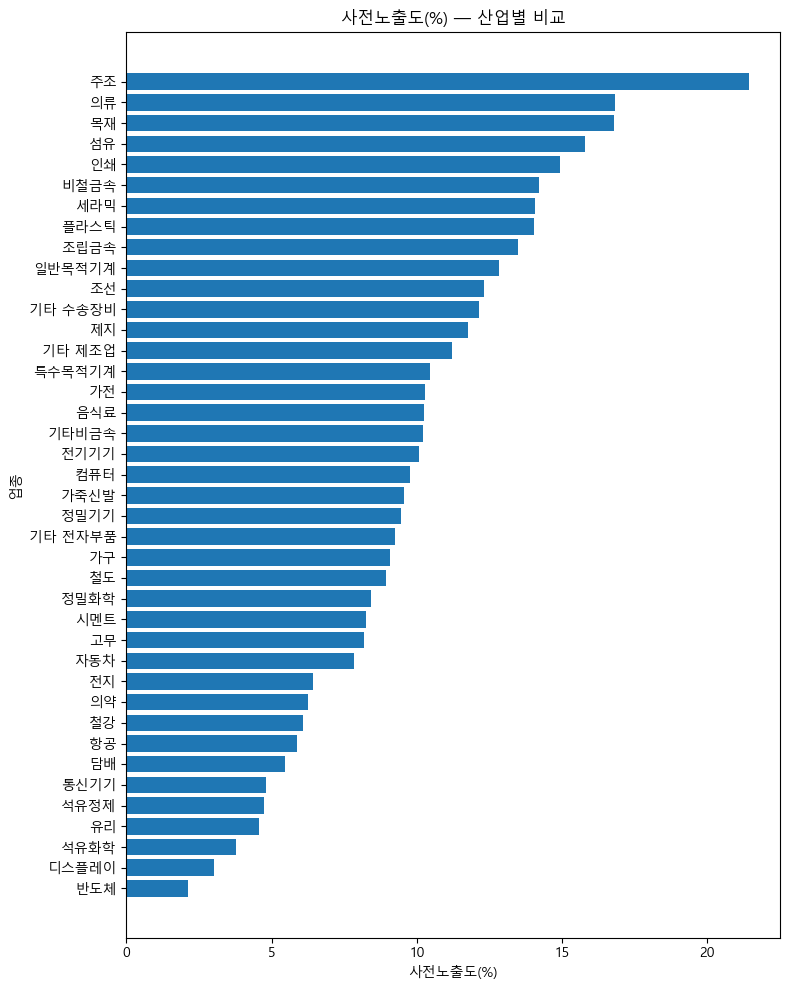

[사전노출도(%)] 상위 10개


,업종코드,업종,사전노출도(%),사전현금여력(%)
162,I3310,주조,21.4399,104.4222
198,I3404,의류,16.8294,154.3305
210,I3406,목재,16.7859,88.7657
192,I3403,섬유,15.7889,117.3476
222,I3408,인쇄,14.9495,97.0503
156,I3309,비철금속,14.2002,167.1528
132,I3305,세라믹,14.0718,144.9210
120,I3303,플라스틱,14.0255,116.3416
168,I3311,조립금속,13.4778,122.3851
78,I3205,일반목적기계,12.8419,113.8186


[사전노출도(%)] 하위 10개


,업종코드,업종,사전노출도(%),사전현금여력(%)
6,I3102,반도체,2.1155,154.9120
12,I3103,디스플레이,3.0012,181.7716
54,I3201,석유화학,3.7902,149.2160
126,I3304,유리,4.5515,159.0873
108,I3301,석유정제,4.7489,123.7808
24,I3105,통신기기,4.8040,160.3400
186,I3402,담배,5.4777,195.0139
48,I3109,항공,5.8840,124.6354
150,I3308,철강,6.0816,175.6793
0,I3101,의약,6.2397,207.2505


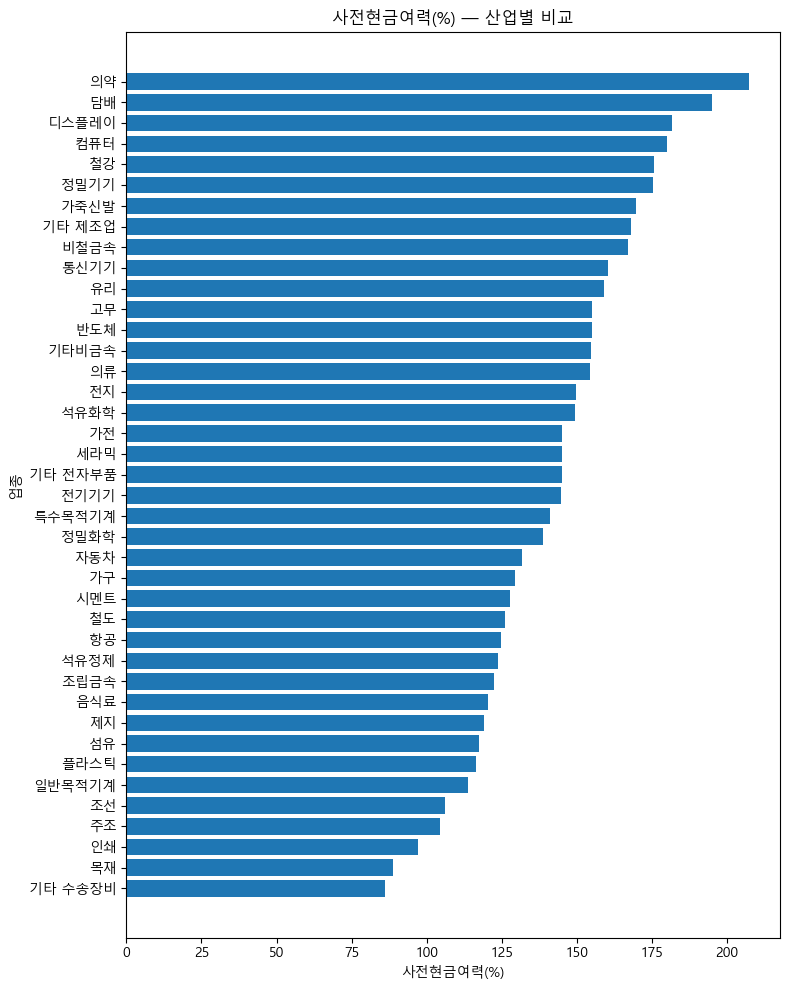

[사전현금여력(%)] 상위 10개


,업종코드,업종,사전노출도(%),사전현금여력(%)
0,I3101,의약,6.2397,207.2505
186,I3402,담배,5.4777,195.0139
12,I3103,디스플레이,3.0012,181.7716
18,I3104,컴퓨터,9.7535,179.9398
150,I3308,철강,6.0816,175.6793
36,I3107,정밀기기,9.4707,175.2469
204,I3405,가죽신발,9.5675,169.7609
234,I3410,기타 제조업,11.2053,167.9191
156,I3309,비철금속,14.2002,167.1528
24,I3105,통신기기,4.8040,160.3400


[사전현금여력(%)] 하위 10개


,업종코드,업종,사전노출도(%),사전현금여력(%)
102,I3209,기타 수송장비,12.1376,86.2049
210,I3406,목재,16.7859,88.7657
222,I3408,인쇄,14.9495,97.0503
162,I3310,주조,21.4399,104.4222
174,I3312,조선,12.3249,106.0230
78,I3205,일반목적기계,12.8419,113.8186
120,I3303,플라스틱,14.0255,116.3416
192,I3403,섬유,15.7889,117.3476
216,I3407,제지,11.7520,119.1702
180,I3401,음식료,10.2493,120.3055


In [12]:

pre_ind = merged[["업종코드","업종","사전노출도(%)","사전현금여력(%)"]].drop_duplicates()

for v in ["사전노출도(%)","사전현금여력(%)"]:
    tmp = pre_ind.sort_values(v)

    plt.figure(figsize=(8,10))
    plt.barh(tmp["업종"], tmp[v])
    plt.title(f"{v} — 산업별 비교")
    plt.xlabel(v)
    plt.ylabel("업종")
    plt.tight_layout()
    plt.show()

    print(f"[{v}] 상위 10개")
    display(tmp.sort_values(v, ascending=False).head(10))
    print(f"[{v}] 하위 10개")
    display(tmp.head(10))


### 사전노출도와 사전현금여력 (긴축기 트랙, 2018~2020 사전기간 기준)

사전노출도와 사전현금여력을 함께 비교하면 산업별 재무구조가 단순히 차입 규모 하나로만 설명되지 않으며, **단기성 차입에 대한 노출 정도와 이를 감당할 수 있는 유동성 여력이 서로 다른 차원으로 나타남**을 확인할 수 있다.

특히 목재(사전노출도 16.79%, 사전현금여력 88.77%), 인쇄(14.95%, 97.05%), 주조(21.44%, 104.42%), 조선(12.32%, 106.02%) 등은 상대적으로 높은 단기차입 노출도와 낮은 유동성 여력이 동시에 나타났다. 이러한 산업은 외부 충격이 발생했을 때 자금조달 부담에 상대적으로 더 민감하게 반응할 가능성을 검토할 필요가 있다.

반대로 반도체(2.12%, 154.91%), 디스플레이(3.00%, 181.77%), 석유화학(3.79%, 149.22%), 통신기기(4.80%, 160.34%) 등은 사전노출도가 낮으면서 유동성 여력이 상대적으로 높은 모습을 보였다.

따라서 분석대상 산업 사이에는 **충격 발생 이전의 재무적 취약성에 상당한 이질성**이 존재한다. 이는 이후 원자재 가격충격의 영향이 모든 산업에서 동일하게 나타날 것이라고 가정하기보다, 사전 차입노출도와 유동성 여력에 따라 충격의 효과가 달라지는지를 검토할 필요가 있음을 보여준다.

다만 사전현금여력은 실제 현금보유액 자체가 아니라 `유동자산 / 유동부채`에 기반한 유동성 지표이므로, 이후 해석에서는 ICR 등 다른 재무지표와 함께 확인한다.

(참고: 평시 트랙에서는 담배·주조가 각각 최저/최고 노출도였으나, 긴축기 트랙(사전기간 2018~2020)에서는 반도체가 최저, 주조는 여전히 상위권이지만 목재·인쇄가 "고노출도·저현금여력" 조합에서 더 두드러진다 — 사전기간 정의(2015~17 vs 2018~20)가 다르므로 트랙별 순위가 일부 달라지는 것은 정상이다.)


# 9. 최종 판정

병합 오류와 원자료 자체 특이값을 분리해서 판단한다.

- 키가 정확히 대응하는가
- 직접 병합값이 원자료와 같은가
- 파생변수가 다시 계산해도 같은가
- 특이값이 원자료에도 같은가

를 모두 종합한다.


In [13]:

all_direct_ok = bad_direct.empty
flag_merge_mismatch = int(flag_summary["그중 원자료 불일치"].sum())

result = pd.DataFrame([
    ["키 구조", all_key_ok, "원자료 3개와 업종코드×연도 1:1 대응"],
    ["직접 병합값", all_direct_ok, "안정성·수익성·원자재 값 직접 대조"],
    ["파생변수", all_derived_ok, "사전노출도·사전현금여력·Post·상호작용항 재계산"],
    ["전체 재구성", all_full_ok, "원자료에서 16개 열 전체 재생성"],
    ["특이점 원자료 대조", flag_merge_mismatch == 0,
     f"특이점 중 병합과정 불일치 {flag_merge_mismatch}건"]
], columns=["검사","통과","해석"])

display(result)

if result["통과"].all():
    msg = (
        "## ✅ 병합 검증 결론\n\n"
        "**현재 `재무_원자재_병합패널.csv`는 원자료 기준으로 정상적으로 병합된 것으로 확인됩니다.**\n\n"
        "- 분석기간의 모든 산업×연도 키가 원자료와 대응\n"
        "- 직접 병합된 값이 원자료와 동일\n"
        "- 파생변수도 원자료에서 동일하게 재현\n"
        "- 그래프에서 튀는 값은 존재하지만, 확인된 특이값은 원자료에도 동일하게 존재하므로 병합 때문에 생긴 값은 아님\n\n"
        "### 별도 확인\n"
        f"`Post`는 현재 파일에서 **{cutoff}년부터 1**입니다. "
        "이 규칙은 파일 내부적으로 일관되지만, 연구설계상 그 연도가 의도한 기준인지 여부는 별도로 확인해야 합니다."
    )
else:
    msg = "## ⚠️ 일부 병합 검증이 통과하지 않았습니다. 위 검사표를 확인하세요."

display(Markdown(msg))


,검사,통과,해석
0,키 구조,True,원자료 3개와 업종코드×연도 1:1 대응
1,직접 병합값,True,안정성·수익성·원자재 값 직접 대조
2,파생변수,True,사전노출도·사전현금여력·Post·상호작용항 재계산
3,전체 재구성,True,원자료에서 16개 열 전체 재생성
4,특이점 원자료 대조,True,특이점 중 병합과정 불일치 0건


## ✅ 병합 검증 결론

**현재 `재무_원자재_병합패널.csv`는 원자료 기준으로 정상적으로 병합된 것으로 확인됩니다.**

- 분석기간의 모든 산업×연도 키가 원자료와 대응
- 직접 병합된 값이 원자료와 동일
- 파생변수도 원자료에서 동일하게 재현
- 그래프에서 튀는 값은 존재하지만, 확인된 특이값은 원자료에도 동일하게 존재하므로 병합 때문에 생긴 값은 아님

### 별도 확인
`Post`는 현재 파일에서 **2022년부터 1**입니다. 이 규칙은 파일 내부적으로 일관되지만, 연구설계상 그 연도가 의도한 기준인지 여부는 별도로 확인해야 합니다.

## Part B. 평시 트랙

In [14]:

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

for f in ["Malgun Gothic", "AppleGothic", "NanumGothic",
          "Pretendard", "Noto Sans CJK KR", "Noto Sans CJK JP"]:
    try:
        mpl.font_manager.findfont(f, fallback_to_default=False)
        mpl.rcParams["font.family"] = f
        break
    except Exception:
        pass
mpl.rcParams["axes.unicode_minus"] = False

def find_file(names):
    candidates = []
    for name in names:
        candidates += [Path(name), Path("/mnt/data") / name]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {names}")

# 이 노트북은 "2. EDA/" 폴더에서 실행하는 것을 기준으로 상대경로를 잡음
BASE = ROOT
p_stab = INTERIM / "ISTANS 안정성" / "안정성_전체통합_1994_2025.csv"
p_prof = INTERIM / "ISTANS 수익성" / "수익성_전체통합_1994_2025.csv"
p_shock = PROCESSED / "원자재_가격충격_패널.csv"
p_merge = PROCESSED / "평시_재무_원자재_병합패널.csv"

for _label, _p in [("안정성", p_stab), ("수익성", p_prof), ("원자재", p_shock), ("병합본", p_merge)]:
    if not _p.exists():
        raise FileNotFoundError(f"{_label} 파일을 못 찾음: {_p.resolve()}")

stab = pd.read_csv(p_stab, encoding="utf-8-sig")
prof = pd.read_csv(p_prof, encoding="utf-8-sig")
shock = pd.read_csv(p_shock, encoding="utf-8-sig")
merged = pd.read_csv(p_merge, encoding="utf-8-sig")

shock = shock.rename(columns={"year":"연도", "industry_code":"업종코드"})

print("안정성:", p_stab, stab.shape)
print("수익성:", p_prof, prof.shape)
print("원자재:", p_shock, shock.shape)
print("병합본:", p_merge, merged.shape)
print("분석기간:", merged["연도"].min(), "~", merged["연도"].max())
print("업종 수:", merged["업종코드"].nunique())
display(merged.head())


안정성: <repo>\data\interim\ISTANS 안정성\안정성_전체통합_1994_2025.csv (1280, 21)
수익성: <repo>\data\interim\ISTANS 수익성\수익성_전체통합_1994_2025.csv (1280, 8)
원자재: <repo>\data\processed\원자재_가격충격_패널.csv (440, 5)
병합본: <repo>\data\processed\평시_재무_원자재_병합패널.csv (200, 16)
분석기간: 2015 ~ 2019
업종 수: 40


,업종코드,업종,연도,자산총계,단기차입,단기사채,차입의존도,ICR,사전노출도(%),Post,사전현금여력(%),Post×사전현금여력,Post×사전노출도,shock_baseline_1111only,shock_extended_1111_1119,diff_1119_effect
0,I3101,의약,2015,"40,519.0000","2,661.0000",0.0000,24.3000,768.4000,6.2302,0,175.6402,0.0000,0.0000,-1.1012,-1.1017,-0.0006
1,I3101,의약,2016,"45,647.0000","2,696.0000",2.0000,20.2000,846.1000,6.2302,0,175.6402,0.0000,0.0000,-0.3715,-0.3715,0.0001
2,I3101,의약,2017,"49,141.0000","3,053.0000",0.0000,19.9000,"1,039.6000",6.2302,0,175.6402,0.0000,0.0000,0.4683,0.4685,0.0002
3,I3101,의약,2018,"52,034.0000","3,057.0000",0.0000,18.6000,700.1000,6.2302,1,175.6402,175.6402,6.2302,0.4747,0.4749,0.0001
4,I3101,의약,2019,"54,757.0000","3,510.0000",0.0000,22.1000,549.9000,6.2302,1,175.6402,175.6402,6.2302,-0.0568,-0.0573,-0.0006



## 1. 키 구조 검증

병합에서 가장 먼저 볼 것은 분포가 아니라 **키가 정확히 맞았는지**다.

분석기간에 맞춰 원자료 3개를 자른 뒤,
- `업종코드 × 연도` 중복
- 키 개수
- 원자료에만 있는 키
- 병합본에만 있는 키

를 확인한다.


In [15]:

YEAR_MIN, YEAR_MAX = int(merged["연도"].min()), int(merged["연도"].max())
KEY = ["업종코드", "연도"]

stab_p = stab[stab["연도"].between(YEAR_MIN, YEAR_MAX)].copy()
prof_p = prof[prof["연도"].between(YEAR_MIN, YEAR_MAX)].copy()
shock_p = shock[shock["연도"].between(YEAR_MIN, YEAR_MAX)].copy()

def key_summary(name, df):
    return {
        "자료": name,
        "행수": len(df),
        "업종수": df["업종코드"].nunique(),
        "연도수": df["연도"].nunique(),
        "키중복수": int(df.duplicated(KEY).sum()),
        "전체결측수": int(df.isna().sum().sum())
    }

key_table = pd.DataFrame([
    key_summary("안정성", stab_p),
    key_summary("수익성", prof_p),
    key_summary("원자재", shock_p),
    key_summary("병합본", merged)
])
display(key_table)

def anti_join(left, right, on=KEY):
    return (
        left[on].drop_duplicates()
        .merge(right[on].drop_duplicates(), on=on, how="left", indicator=True)
        .query('_merge == "left_only"')
        .drop(columns="_merge")
    )

coverage = []
for name, src in [("안정성", stab_p), ("수익성", prof_p), ("원자재", shock_p)]:
    src_only = anti_join(src, merged)
    merged_only = anti_join(merged, src)
    coverage.append({
        "원자료": name,
        "원자료에만 있는 키": len(src_only),
        "병합본에만 있는 키": len(merged_only)
    })

coverage = pd.DataFrame(coverage)
display(coverage)

all_key_ok = (
    key_table["키중복수"].sum() == 0 and
    coverage[["원자료에만 있는 키","병합본에만 있는 키"]].to_numpy().sum() == 0
)
display(Markdown(
    "**✅ 키 기준 병합 구조 정상:** 모든 `업종코드 × 연도`가 1:1로 대응합니다."
    if all_key_ok else
    "**⚠️ 키 불일치가 있습니다.**"
))


,자료,행수,업종수,연도수,키중복수,전체결측수
0,안정성,200,40,5,0,0
1,수익성,200,40,5,0,0
2,원자재,200,40,5,0,0
3,병합본,200,40,5,0,0


,원자료,원자료에만 있는 키,병합본에만 있는 키
0,안정성,0,0
1,수익성,0,0
2,원자재,0,0


**✅ 키 기준 병합 구조 정상:** 모든 `업종코드 × 연도`가 1:1로 대응합니다.


## 2. 원자료 값 직접 대조

병합본에서 원자료로부터 직접 가져온 변수는 다음처럼 대응된다.

- **안정성:** `업종`, `자산총계`, `단기차입`, `단기사채`, `차입의존도`
- **수익성:** `이자보상비율` → 병합본의 `ICR`
- **원자재:** 세 shock 변수

상관계수가 아니라 **같은 업종·같은 연도의 값 자체가 동일한지** 확인한다.


In [16]:

audit = merged.copy()

audit = audit.merge(
    stab_p[["업종코드","연도","업종","자산총계","단기차입","단기사채","차입의존도"]],
    on=KEY, how="left", validate="one_to_one",
    suffixes=("", "_안정성원자료")
)

audit = audit.merge(
    prof_p[["업종코드","연도","이자보상비율"]],
    on=KEY, how="left", validate="one_to_one"
)

shock_cols = ["shock_baseline_1111only","shock_extended_1111_1119","diff_1119_effect"]
audit = audit.merge(
    shock_p[KEY + shock_cols],
    on=KEY, how="left", validate="one_to_one",
    suffixes=("", "_원자재원자료")
)

checks = []

checks.append({
    "병합 변수":"업종", "원자료":"안정성", "비교 변수":"업종",
    "일치":int((audit["업종"] == audit["업종_안정성원자료"]).sum()),
    "전체":len(audit), "최대 절대차":np.nan
})

for c in ["자산총계","단기차입","단기사채","차입의존도"]:
    d = (audit[c] - audit[f"{c}_안정성원자료"]).abs()
    checks.append({
        "병합 변수":c, "원자료":"안정성", "비교 변수":c,
        "일치":int(np.isclose(audit[c], audit[f"{c}_안정성원자료"], equal_nan=True).sum()),
        "전체":len(audit), "최대 절대차":float(d.max())
    })

d = (audit["ICR"] - audit["이자보상비율"]).abs()
checks.append({
    "병합 변수":"ICR", "원자료":"수익성", "비교 변수":"이자보상비율",
    "일치":int(np.isclose(audit["ICR"], audit["이자보상비율"], equal_nan=True).sum()),
    "전체":len(audit), "최대 절대차":float(d.max())
})

for c in shock_cols:
    d = (audit[c] - audit[f"{c}_원자재원자료"]).abs()
    checks.append({
        "병합 변수":c, "원자료":"원자재", "비교 변수":c,
        "일치":int(np.isclose(audit[c], audit[f"{c}_원자재원자료"], equal_nan=True).sum()),
        "전체":len(audit), "최대 절대차":float(d.max())
    })

value_audit = pd.DataFrame(checks)
value_audit["일치율(%)"] = value_audit["일치"] / value_audit["전체"] * 100
display(value_audit)

bad_direct = value_audit[value_audit["일치"] != value_audit["전체"]]
display(Markdown(
    "**✅ 직접 병합된 모든 변수의 값이 원자료와 100% 일치합니다.**"
    if bad_direct.empty else
    "**⚠️ 직접 병합값 불일치가 발견됐습니다.**"
))
if not bad_direct.empty:
    display(bad_direct)


,병합 변수,원자료,비교 변수,일치,전체,최대 절대차,일치율(%)
0,업종,안정성,업종,200,200,NaN,100.0000
1,자산총계,안정성,자산총계,200,200,0.0000,100.0000
2,단기차입,안정성,단기차입,200,200,0.0000,100.0000
3,단기사채,안정성,단기사채,200,200,0.0000,100.0000
4,차입의존도,안정성,차입의존도,200,200,0.0000,100.0000
5,ICR,수익성,이자보상비율,200,200,0.0000,100.0000
6,shock_baseline_1111only,원자재,shock_baseline_1111only,200,200,0.0000,100.0000
7,shock_extended_1111_1119,원자재,shock_extended_1111_1119,200,200,0.0000,100.0000
8,diff_1119_effect,원자재,diff_1119_effect,200,200,0.0000,100.0000


**✅ 직접 병합된 모든 변수의 값이 원자료와 100% 일치합니다.**


## 3. 파생변수 재계산

현재 파일에서 확인되는 구조를 원자료로 다시 계산한다.

- `사전노출도(%)` = `Post=0` 기간의 `(단기차입 + 단기사채) / 자산총계 × 100` 평균
- `사전현금여력(%)` = `Post=0` 기간의 `유동자산 / 유동부채 × 100` 평균
- `Post` = 단일 시점 이후 1
- 상호작용항 = `Post × 사전값`

※ **Post 시작연도 자체가 연구설계상 맞는지는 병합 오류와 별개**다.


In [17]:

post_by_year = merged.groupby("연도")["Post"].agg(["min","max","mean","nunique"])
display(post_by_year)

post_years = sorted(merged.loc[merged["Post"] == 1, "연도"].unique())
pre_years  = sorted(merged.loc[merged["Post"] == 0, "연도"].unique())
cutoff = min(post_years) if post_years else None

print("사전기간:", pre_years)
print("Post=1 기간:", post_years)
print("cutoff:", cutoff)

pre_raw = stab[stab["연도"].isin(pre_years)].copy()
pre_raw["노출도_t"] = (pre_raw["단기차입"] + pre_raw["단기사채"]) / pre_raw["자산총계"] * 100
pre_raw["현금여력_t"] = pre_raw["유동자산"] / pre_raw["유동부채"] * 100

pre_calc = (
    pre_raw.groupby("업종코드", as_index=False)
    .agg(
        사전노출도_재계산=("노출도_t","mean"),
        사전현금여력_재계산=("현금여력_t","mean")
    )
)

der = merged.merge(pre_calc, on="업종코드", how="left", validate="many_to_one")
der["Post_재계산"] = (der["연도"] >= cutoff).astype(int)
der["Post×사전노출도_재계산"] = der["Post_재계산"] * der["사전노출도_재계산"]
der["Post×사전현금여력_재계산"] = der["Post_재계산"] * der["사전현금여력_재계산"]

rows = []
pairs = [
    ("사전노출도(%)","사전노출도_재계산"),
    ("사전현금여력(%)","사전현금여력_재계산"),
    ("Post","Post_재계산"),
    ("Post×사전노출도","Post×사전노출도_재계산"),
    ("Post×사전현금여력","Post×사전현금여력_재계산")
]
for a,b in pairs:
    match = np.isclose(der[a], der[b], rtol=1e-12, atol=1e-12, equal_nan=True)
    rows.append([a, int(match.sum()), len(der), (der[a]-der[b]).abs().max()])

derived_checks = pd.DataFrame(rows, columns=["파생변수","일치","전체","최대 절대차"])
derived_checks["일치율(%)"] = derived_checks["일치"]/derived_checks["전체"]*100
display(derived_checks)

all_derived_ok = (derived_checks["일치"] == len(der)).all()
display(Markdown(
    "**✅ 파생변수도 원자료로 재계산한 값과 모두 일치합니다.**"
    if all_derived_ok else
    "**⚠️ 파생변수 중 불일치가 있습니다.**"
))


,min,max,mean,nunique
연도,,,,
2015,0,0,0.0000,1
2016,0,0,0.0000,1
2017,0,0,0.0000,1
2018,1,1,1.0000,1
2019,1,1,1.0000,1


사전기간: [np.int64(2015), np.int64(2016), np.int64(2017)]
Post=1 기간: [np.int64(2018), np.int64(2019)]
cutoff: 2018


,파생변수,일치,전체,최대 절대차,일치율(%)
0,사전노출도(%),200,200,0.0000,100.0000
1,사전현금여력(%),200,200,0.0000,100.0000
2,Post,200,200,0.0000,100.0000
3,Post×사전노출도,200,200,0.0000,100.0000
4,Post×사전현금여력,200,200,0.0000,100.0000


**✅ 파생변수도 원자료로 재계산한 값과 모두 일치합니다.**


## 4. 원자료에서 병합파일 전체 재구성

원자료 3개만 이용해 현재 병합파일과 같은 구조를 다시 만든 뒤 16개 열 전체를 비교한다.


In [18]:

expected = stab_p[["업종코드","업종","연도","자산총계","단기차입","단기사채","차입의존도"]].copy()

expected = expected.merge(
    prof_p[["업종코드","연도","이자보상비율"]],
    on=KEY, how="left", validate="one_to_one"
).rename(columns={"이자보상비율":"ICR"})

expected = expected.merge(
    pre_calc.rename(columns={
        "사전노출도_재계산":"사전노출도(%)",
        "사전현금여력_재계산":"사전현금여력(%)"
    }),
    on="업종코드", how="left", validate="many_to_one"
)

expected["Post"] = (expected["연도"] >= cutoff).astype(int)
expected["Post×사전현금여력"] = expected["Post"] * expected["사전현금여력(%)"]
expected["Post×사전노출도"] = expected["Post"] * expected["사전노출도(%)"]

expected = expected.merge(
    shock_p[KEY + shock_cols],
    on=KEY, how="left", validate="one_to_one"
)

expected = expected[merged.columns].sort_values(KEY).reset_index(drop=True)
actual = merged.sort_values(KEY).reset_index(drop=True)

full_compare = []
for c in actual.columns:
    if pd.api.types.is_numeric_dtype(actual[c]):
        match = np.isclose(actual[c], expected[c], rtol=1e-12, atol=1e-12, equal_nan=True)
        maxdiff = float((actual[c]-expected[c]).abs().max())
    else:
        match = actual[c].eq(expected[c]).to_numpy()
        maxdiff = np.nan
    full_compare.append({
        "변수":c, "일치":int(match.sum()), "전체":len(actual),
        "일치율(%)":match.mean()*100, "최대 절대차":maxdiff
    })

full_compare = pd.DataFrame(full_compare)
display(full_compare)

all_full_ok = (full_compare["일치"] == full_compare["전체"]).all()
display(Markdown(
    "**✅ 현재 병합파일은 원자료에서 동일하게 재구성됩니다.**"
    if all_full_ok else
    "**⚠️ 전체 재구성 비교에서 불일치가 있습니다.**"
))


,변수,일치,전체,일치율(%),최대 절대차
0,업종코드,200,200,100.0000,NaN
1,업종,200,200,100.0000,NaN
2,연도,200,200,100.0000,0.0000
3,자산총계,200,200,100.0000,0.0000
4,단기차입,200,200,100.0000,0.0000
5,단기사채,200,200,100.0000,0.0000
6,차입의존도,200,200,100.0000,0.0000
7,ICR,200,200,100.0000,0.0000
8,사전노출도(%),200,200,100.0000,0.0000
9,Post,200,200,100.0000,0.0000


**✅ 현재 병합파일은 원자료에서 동일하게 재구성됩니다.**


# 5. 변수별·산업별 간단 EDA

병합이 맞더라도 원자료 자체에 특이값은 있을 수 있다.

### 그래프 선택
- `자산총계`, `단기차입`: 규모 차이가 커서 y축을 `symlog`로 본다.
- `차입의존도`, `ICR`, `원자재충격`: 원척도 box plot
- `단기사채`: 0이 많은 희소변수라 0 비율 + 상위값
- `Post` 및 상호작용항은 기계적으로 생성되므로 별도 그래프를 생략


In [19]:

eda_vars = [
    "자산총계","단기차입","단기사채","차입의존도","ICR",
    "사전노출도(%)","사전현금여력(%)",
    "shock_baseline_1111only","shock_extended_1111_1119","diff_1119_effect"
]
display(merged[eda_vars].describe().T)


,count,mean,std,min,25%,50%,75%,max
자산총계,200.0000,"42,729.1150","55,791.0293",796.0000,"6,617.7500","23,264.0000","53,735.0000","267,160.0000"
단기차입,200.0000,"3,353.9500","3,649.5215",75.0000,602.5000,"2,200.5000","4,791.0000","20,685.0000"
단기사채,200.0000,6.0200,28.2610,0.0000,0.0000,0.0000,1.0000,298.0000
차입의존도,200.0000,39.6435,24.5921,1.2000,28.8750,34.8000,48.1000,267.5000
ICR,200.0000,"1,071.2200","3,157.8607","-2,655.1000",341.0250,534.9000,834.9250,"30,658.3000"
사전노출도(%),200.0000,10.4495,4.6953,2.1656,6.8308,10.7428,13.2399,21.9698
사전현금여력(%),200.0000,141.5736,28.7647,86.1826,123.2201,143.8414,156.9669,201.0193
shock_baseline_1111only,200.0000,-0.2437,3.1749,-33.3179,-0.7071,-0.0917,0.5120,13.9662
shock_extended_1111_1119,200.0000,-0.2452,3.1754,-33.3181,-0.7071,-0.0953,0.5165,13.9663
diff_1119_effect,200.0000,-0.0015,0.0176,-0.1672,-0.0006,0.0001,0.0002,0.0646


<python-env> MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=years, showfliers=True)


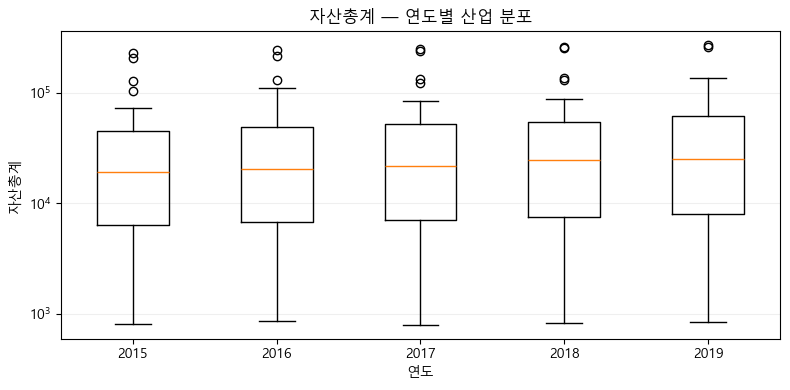

<python-env> MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=years, showfliers=True)


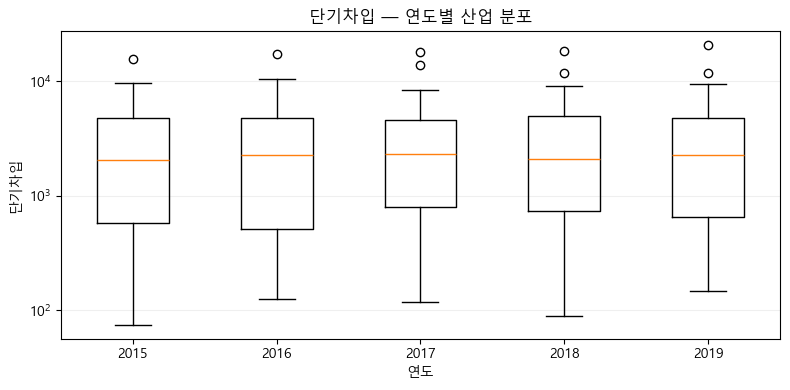

<python-env> MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=years, showfliers=True)


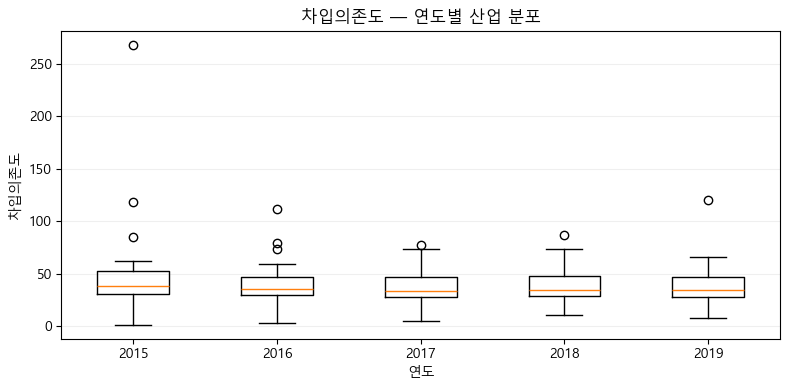

<python-env> MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=years, showfliers=True)
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


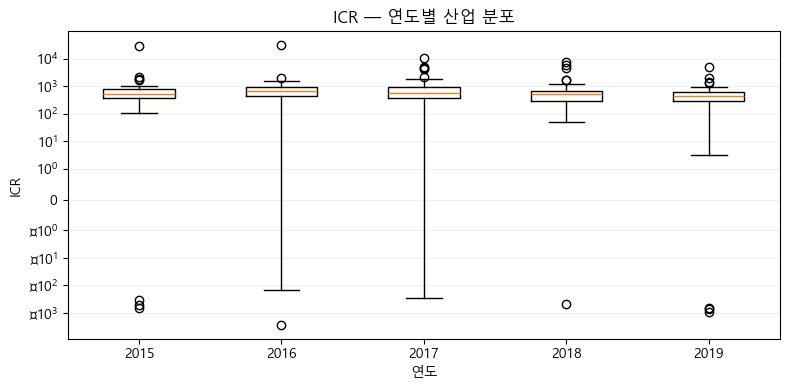

<python-env> MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=years, showfliers=True)


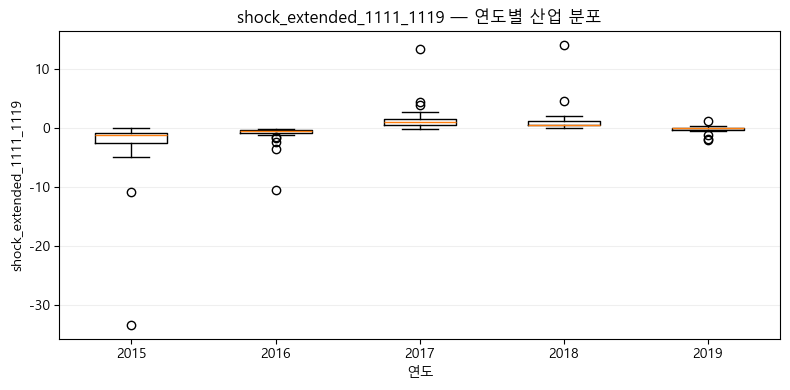

In [20]:

def year_boxplot(var, symlog=False):
    years = sorted(merged["연도"].unique())
    vals = [merged.loc[merged["연도"]==y, var].dropna().to_numpy() for y in years]
    plt.figure(figsize=(8,4))
    plt.boxplot(vals, labels=years, showfliers=True)
    plt.title(f"{var} — 연도별 산업 분포")
    plt.xlabel("연도")
    plt.ylabel(var)
    if symlog:
        plt.yscale("symlog", linthresh=1)
    plt.grid(axis="y", alpha=.2)
    plt.tight_layout()
    plt.show()

for v in ["자산총계","단기차입","차입의존도","ICR","shock_extended_1111_1119"]:
    year_boxplot(v, symlog=(v in ["자산총계","단기차입","ICR"]))



### 단기사채: 0 비율과 상위값

0이 많은 변수는 일반적인 IQR box plot이 지나치게 민감할 수 있어 따로 본다.


,관측수,영인개수,비영개수,0비율(%)
연도,,,,
2015,40,32,8,80.0000
2016,40,30,10,75.0000
2017,40,25,15,62.5000
2018,40,29,11,72.5000
2019,40,27,13,67.5000


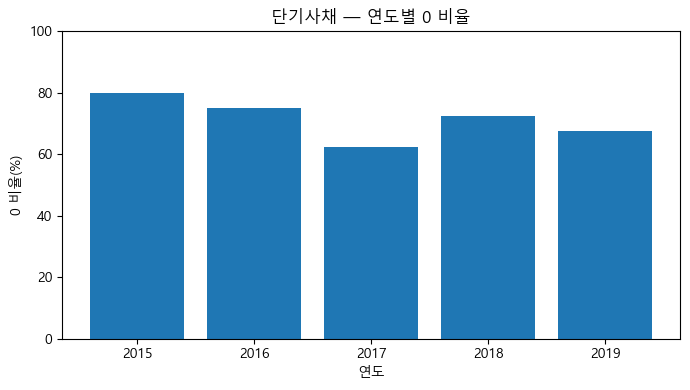

,업종코드,업종,연도,단기사채
167,I3404,의류,2017,298.0000
147,I3312,조선,2017,173.0000
115,I3306,시멘트,2015,157.0000
78,I3207,자동차,2018,86.0000
118,I3306,시멘트,2018,77.0000
59,I3203,기타 전자부품,2019,53.0000
57,I3203,기타 전자부품,2017,43.0000
165,I3404,의류,2015,33.0000
119,I3306,시멘트,2019,32.0000
72,I3206,특수목적기계,2017,28.0000


In [21]:

bond_zero = (
    merged.groupby("연도")["단기사채"]
    .agg(관측수="size", 영인개수=lambda s:(s==0).sum(), 비영개수=lambda s:(s!=0).sum())
)
bond_zero["0비율(%)"] = bond_zero["영인개수"]/bond_zero["관측수"]*100
display(bond_zero)

plt.figure(figsize=(7,4))
plt.bar(bond_zero.index.astype(str), bond_zero["0비율(%)"])
plt.ylim(0,100)
plt.title("단기사채 — 연도별 0 비율")
plt.xlabel("연도")
plt.ylabel("0 비율(%)")
plt.tight_layout()
plt.show()

display(
    merged.loc[merged["단기사채"]>0, ["업종코드","업종","연도","단기사채"]]
    .sort_values("단기사채", ascending=False)
    .head(20)
)



## 6. 산업×연도 heatmap

연도별 중앙값과 MAD를 이용해 상대적 특이도를 표시한다.

- 행을 따라 한 연도만 갑자기 튀는 산업
- 모든 연도에서 지속적으로 높은 산업

을 빠르게 찾는 용도다.


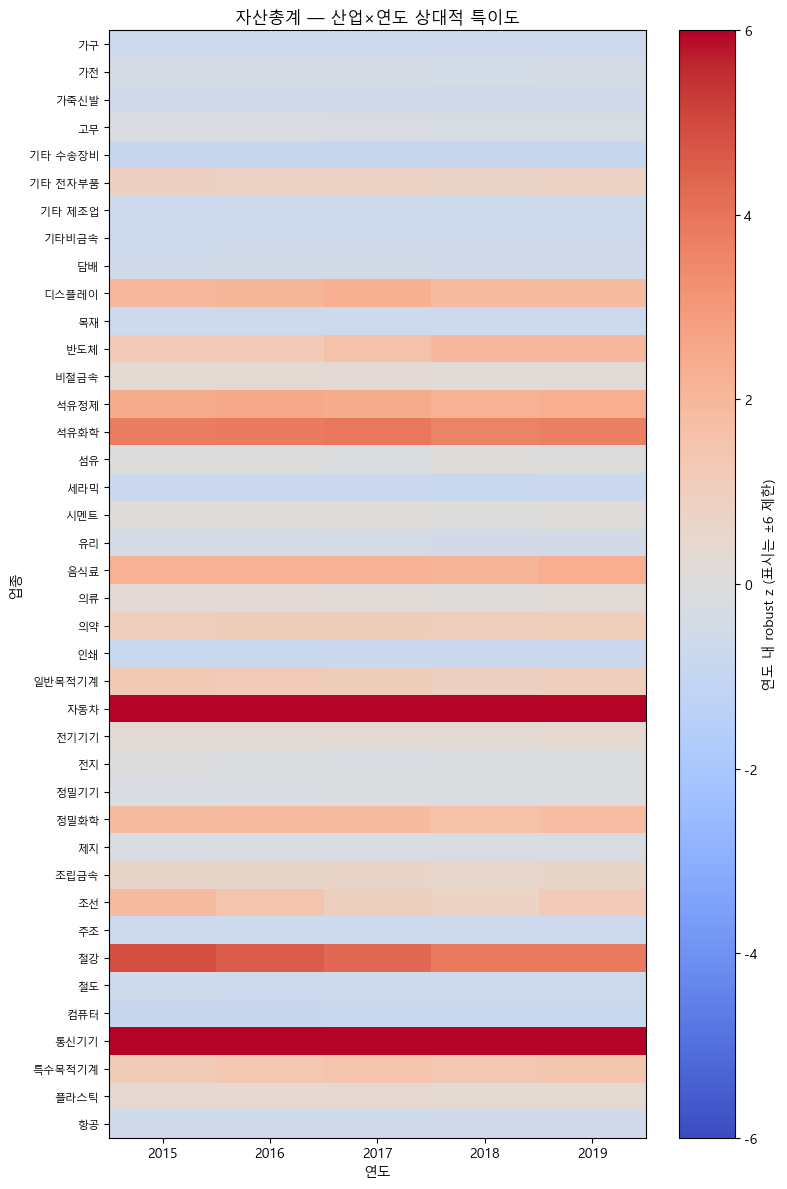

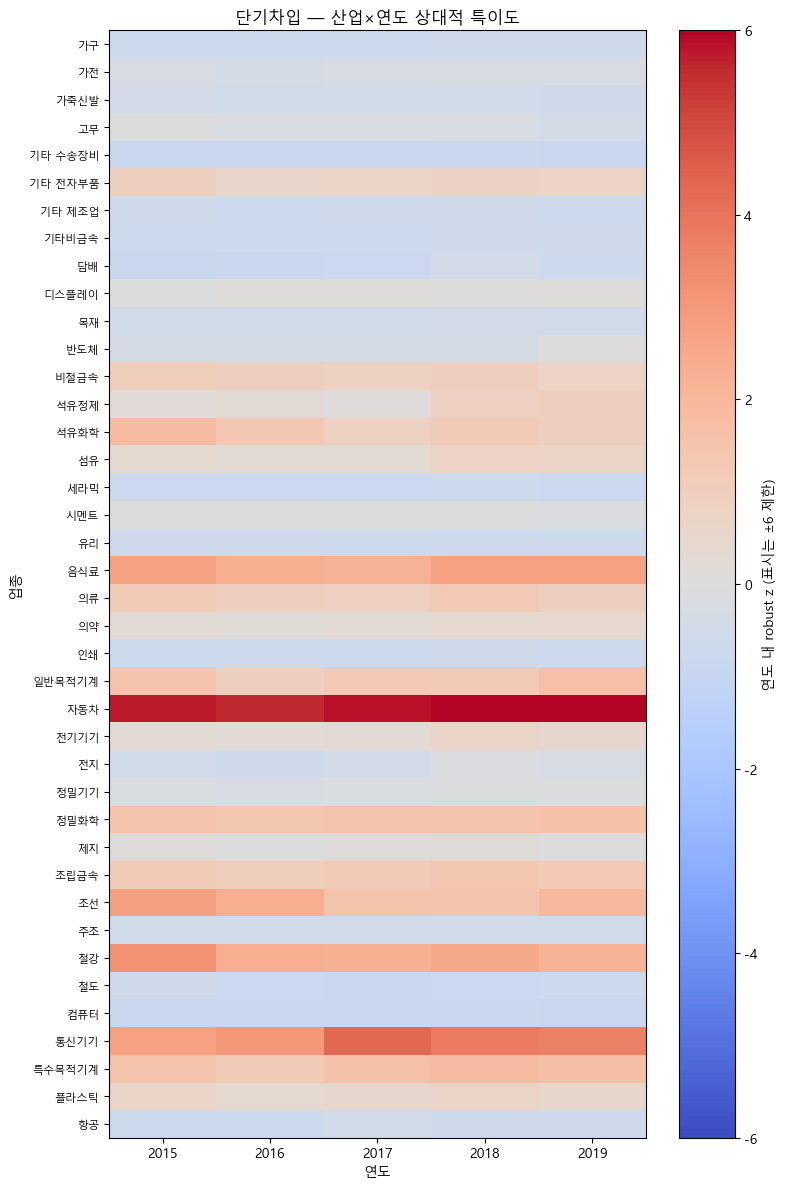

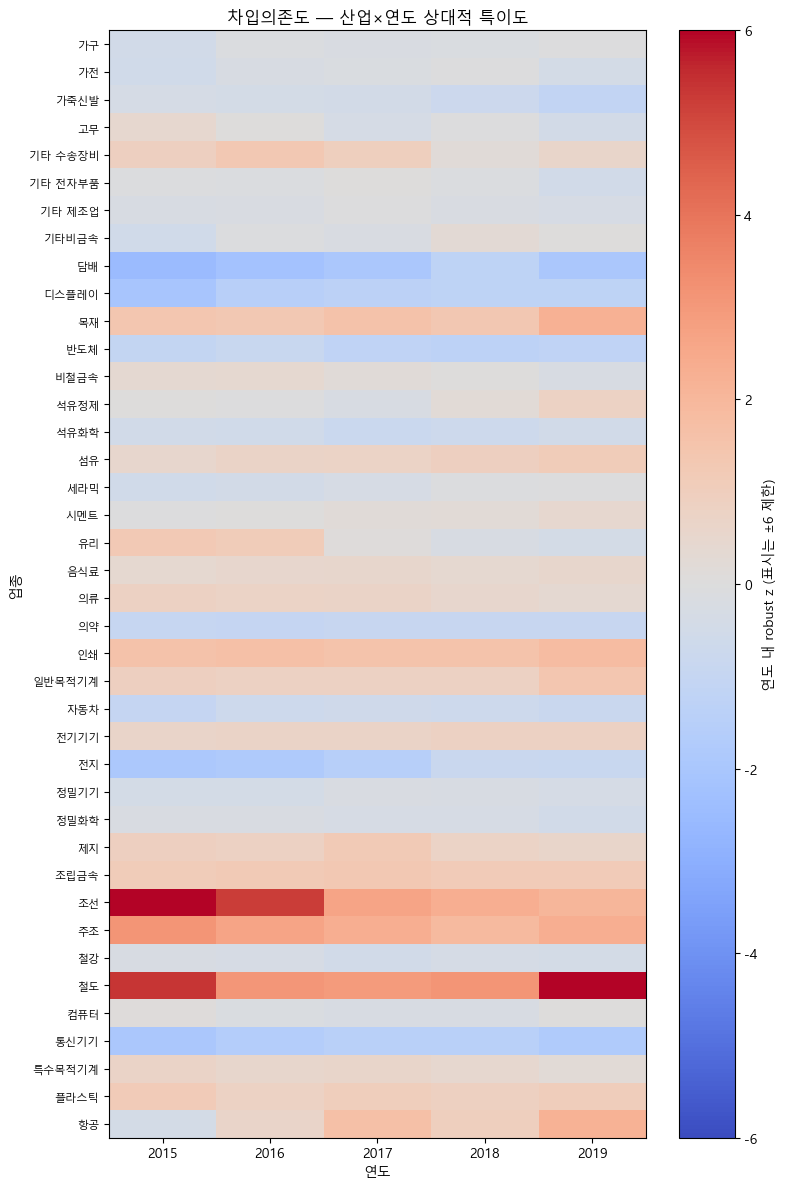

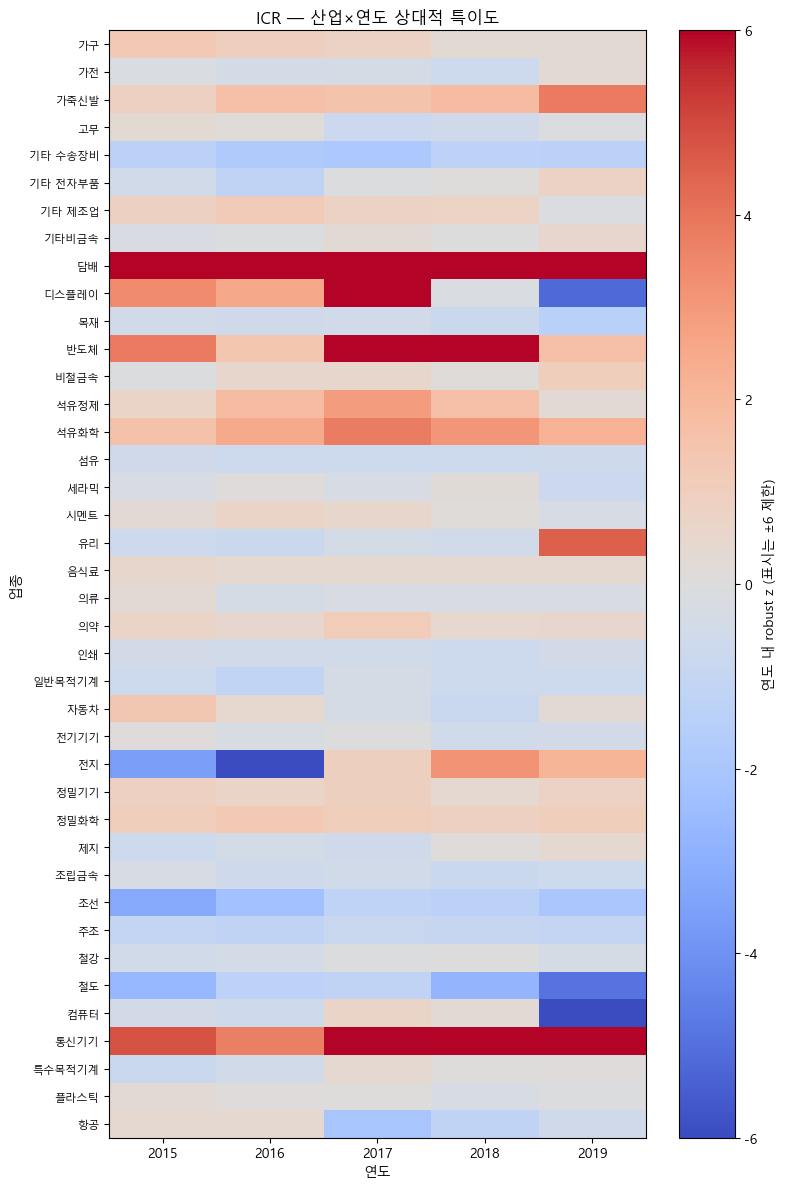

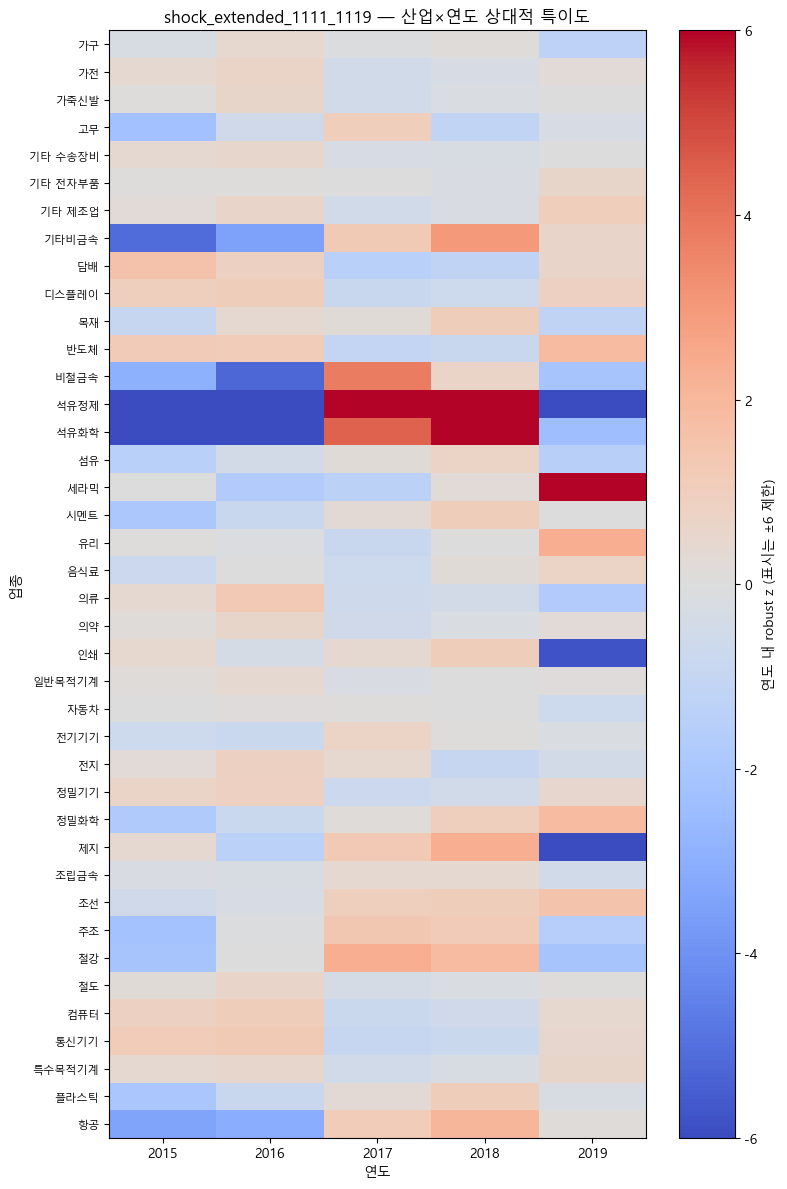

In [22]:

def industry_heatmap(var):
    p = merged.pivot(index="업종", columns="연도", values=var)
    z = p.copy().astype(float)

    for y in z.columns:
        s = z[y]
        med = s.median()
        mad = (s-med).abs().median()
        z[y] = (s-med)/(1.4826*mad) if mad > 0 else 0.0

    arr = np.clip(z.to_numpy(), -6, 6)

    plt.figure(figsize=(8,12))
    im = plt.imshow(arr, aspect="auto", interpolation="nearest",
                    cmap="coolwarm", vmin=-6, vmax=6)
    plt.colorbar(im, label="연도 내 robust z (표시는 ±6 제한)")
    plt.yticks(range(len(z.index)), z.index, fontsize=8)
    plt.xticks(range(len(z.columns)), z.columns)
    plt.title(f"{var} — 산업×연도 상대적 특이도")
    plt.xlabel("연도")
    plt.ylabel("업종")
    plt.tight_layout()
    plt.show()

for v in ["자산총계","단기차입","차입의존도","ICR","shock_extended_1111_1119"]:
    industry_heatmap(v)


### 산업×연도 Heatmap 해석

각 연도별로 40개 산업의 값을 중앙값과 MAD(Median Absolute Deviation)를 이용해 robust z-score로 변환하였다.  
따라서 색상은 변수의 절대적인 크기가 아니라 **같은 연도의 다른 산업과 비교했을 때 상대적으로 높은지 또는 낮은지**를 나타낸다.

- 붉은색: 해당 연도 산업 중앙값보다 상대적으로 높은 값
- 푸른색: 해당 연도 산업 중앙값보다 상대적으로 낮은 값
- 회색에 가까운 색: 해당 연도의 산업 중앙 수준과 비슷한 값
- 색이 진할수록 다른 산업과의 상대적인 차이가 큼

주의할 점은 붉은색이 반드시 좋은 값 또는 양수이고, 푸른색이 나쁜 값 또는 음수라는 의미는 아니라는 것이다. 또한 연도별로 다시 표준화했기 때문에 서로 다른 연도의 색상 크기를 절대값처럼 직접 비교할 수 없다.

#### 자산총계

자동차, 통신기기, 철강, 석유화학 등 일부 산업은 분석기간 동안 지속적으로 다른 산업보다 높은 자산규모를 보인다. 반대로 일부 산업은 지속적으로 상대적으로 작은 자산규모를 나타낸다.

대부분의 산업에서 연도별 상대적 위치가 크게 변하지 않아, 특정 산업의 특정 연도 값이 갑자기 비정상적으로 변한 패턴은 두드러지지 않는다. 따라서 현재 heatmap에서는 병합 과정에서 발생한 뚜렷한 단년도 오류 징후는 확인되지 않았다.

다만 자산총계는 산업 규모의 영향을 크게 받는 변수이므로, 특정 산업 내에서 값이 갑자기 변했는지를 확인하기 위해서는 전년 대비 증감률을 추가로 확인하는 것이 더 적절하다.

#### 단기차입

단기차입에서도 자동차, 통신기기, 철강 등 일부 산업이 지속적으로 높은 상대적 수준을 보인다. 자산총계와 유사한 산업별 규모 차이가 나타나지만, 두 변수의 패턴이 완전히 동일하지는 않는다.

특정 한 해에만 상대적 위치가 급격히 바뀌는 산업은 많지 않아, 단기차입 역시 병합 과정에서 특정 산업·연도 값이 잘못 들어간 것으로 보이는 뚜렷한 패턴은 확인되지 않았다.

단기차입 역시 절대금액은 산업 규모의 영향을 받으므로, 이후 분석에서는 차입의존도와 함께 확인할 필요가 있다.

#### ICR

ICR은 자산총계나 단기차입보다 산업별·연도별 변화가 크게 나타난다. 담배와 통신기기 등은 분석기간 동안 상대적으로 높은 ICR을 유지하는 반면, 디스플레이와 컴퓨터 등 일부 산업은 특정 연도에 상대적 위치가 크게 변화한다.

이는 ICR이 산업 규모보다는 영업이익과 이자비용의 변화에 민감한 변수이기 때문에 나타날 수 있는 패턴이다.

특히 한 산업의 색상이 연도에 따라 크게 변하는 경우 실제 값을 추가로 확인할 필요가 있다. 다만 해당 관측값들은 원자료와 직접 대조한 결과 병합파일과 동일하게 나타났으므로, 현재 관찰되는 큰 변화는 병합 과정에서 발생한 오류라기보다 원자료 자체의 산업별 실적 변동으로 볼 수 있다.

#### 원자재 가격충격

원자재 가격충격은 산업과 연도에 따라 상대적 위치가 크게 변화한다. 특히 석유정제와 석유화학 등에서는 연도별 색상 변화가 크게 나타나며, 철강·비철금속 등에서도 비교적 큰 변화가 확인된다.

이는 원자재 가격충격이 단순한 산업별 고정 특성이 아니라 **연도별 원자재 가격 변화와 산업별 원자재 노출구조가 함께 반영된 변수**이기 때문에 나타나는 패턴으로 해석할 수 있다.

따라서 같은 연도에도 산업별 충격 수준에 차이가 존재하며, 이후 패널분석에서 활용할 수 있는 산업×연도 변동이 존재함을 확인할 수 있다.

### 종합

자산총계와 단기차입은 분석기간 동안 산업별 상대적 위치가 비교적 안정적으로 유지되는 반면, ICR과 원자재 가격충격은 산업 및 연도에 따라 상대적 위치 변화가 더 크게 나타났다.

Heatmap에서 일부 특이한 산업×연도 조합이 확인되었으나, 해당 값들을 원자료와 대조한 결과 병합파일과 동일하게 나타났다. 따라서 현재 확인된 특이 패턴은 병합 과정에서 발생한 오류라기보다 원자료 자체의 산업별·연도별 이질성에 따른 것으로 판단하였다.


## 7. IQR 기준 검토 대상

연도별 `Q1 - 1.5×IQR`, `Q3 + 1.5×IQR` 밖의 값을 추린다.

**주의:** 이 표는 오류 목록이 아니다.  
산업자료에서는 실제 산업구조 때문에 큰 값이 자연스럽게 존재할 수 있다.

같은 셀의 원자료 값도 함께 붙여서,
- `원자료일치=True` → 병합 오류가 아니라 원자료부터 존재한 특이값
- `False` → 병합 과정 확인 필요

로 해석한다.


In [23]:

source_map = {
    "자산총계":("안정성", "자산총계_안정성원자료"),
    "단기차입":("안정성", "단기차입_안정성원자료"),
    "차입의존도":("안정성", "차입의존도_안정성원자료"),
    "ICR":("수익성", "이자보상비율"),
    "shock_extended_1111_1119":("원자재", "shock_extended_1111_1119_원자재원자료")
}

def iqr_review_table(var):
    out = []
    for y, g in audit.groupby("연도"):
        s = g[var].dropna()
        q1, q3 = s.quantile([.25,.75])
        iqr = q3-q1
        lo, hi = q1-1.5*iqr, q3+1.5*iqr
        f = g[(g[var] < lo) | (g[var] > hi)].copy()
        if len(f):
            src_name, src_col = source_map[var]
            f["원자료"] = src_name
            f["원자료값"] = f[src_col]
            f["원자료일치"] = np.isclose(f[var], f[src_col], equal_nan=True)
            f["하한"] = lo
            f["상한"] = hi
            out.append(f[["업종코드","업종","연도",var,"원자료","원자료값","원자료일치","하한","상한"]])
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

flag_summary = []
flag_tables = {}

for v in source_map:
    f = iqr_review_table(v)
    flag_tables[v] = f
    flag_summary.append({
        "변수":v,
        "검토대상 수":len(f),
        "그중 원자료 불일치":int((~f["원자료일치"]).sum()) if len(f) else 0
    })

flag_summary = pd.DataFrame(flag_summary)
display(flag_summary)

for v, f in flag_tables.items():
    display(Markdown(f"### {v}"))
    if len(f):
        display(f.sort_values(v).head(10))
        if len(f) > 10:
            display(Markdown("**큰 값 쪽**"))
            display(f.sort_values(v, ascending=False).head(10))
    else:
        print("IQR fence 밖 관측치 없음")


,변수,검토대상 수,그중 원자료 불일치
0,자산총계,17,0
1,단기차입,8,0
2,차입의존도,9,0
3,ICR,28,0
4,shock_extended_1111_1119,16,0


### 자산총계

,업종코드,업종,연도,자산총계,원자료,원자료값,원자료일치,하한,상한
1,I3201,석유화학,2015,"103,535.0000",안정성,"103,535.0000",True,"-51,661.7500","102,928.2500"
8,I3201,석유화학,2017,"122,682.0000",안정성,"122,682.0000",True,"-59,859.5000","118,718.5000"
3,I3308,철강,2015,"127,213.0000",안정성,"127,213.0000",True,"-51,661.7500","102,928.2500"
12,I3201,석유화학,2018,"128,508.0000",안정성,"128,508.0000",True,"-63,236.1250","125,180.8750"
6,I3308,철강,2016,"129,013.0000",안정성,"129,013.0000",True,"-56,185.6250","111,817.3750"
10,I3308,철강,2017,"132,561.0000",안정성,"132,561.0000",True,"-59,859.5000","118,718.5000"
14,I3308,철강,2018,"134,217.0000",안정성,"134,217.0000",True,"-63,236.1250","125,180.8750"
0,I3105,통신기기,2015,"205,422.0000",안정성,"205,422.0000",True,"-51,661.7500","102,928.2500"
4,I3105,통신기기,2016,"212,563.0000",안정성,"212,563.0000",True,"-56,185.6250","111,817.3750"
2,I3207,자동차,2015,"227,099.0000",안정성,"227,099.0000",True,"-51,661.7500","102,928.2500"


**큰 값 쪽**

,업종코드,업종,연도,자산총계,원자료,원자료값,원자료일치,하한,상한
16,I3207,자동차,2019,"267,160.0000",안정성,"267,160.0000",True,"-71,481.2500","140,294.7500"
11,I3105,통신기기,2018,"259,692.0000",안정성,"259,692.0000",True,"-63,236.1250","125,180.8750"
15,I3105,통신기기,2019,"257,766.0000",안정성,"257,766.0000",True,"-71,481.2500","140,294.7500"
13,I3207,자동차,2018,"251,229.0000",안정성,"251,229.0000",True,"-63,236.1250","125,180.8750"
9,I3207,자동차,2017,"246,740.0000",안정성,"246,740.0000",True,"-59,859.5000","118,718.5000"
5,I3207,자동차,2016,"240,715.0000",안정성,"240,715.0000",True,"-56,185.6250","111,817.3750"
7,I3105,통신기기,2017,"238,159.0000",안정성,"238,159.0000",True,"-59,859.5000","118,718.5000"
2,I3207,자동차,2015,"227,099.0000",안정성,"227,099.0000",True,"-51,661.7500","102,928.2500"
4,I3105,통신기기,2016,"212,563.0000",안정성,"212,563.0000",True,"-56,185.6250","111,817.3750"
0,I3105,통신기기,2015,"205,422.0000",안정성,"205,422.0000",True,"-51,661.7500","102,928.2500"


...

,업종코드,업종,연도,ICR,원자료,원자료값,원자료일치,하한,상한
9,I3402,담배,2016,"30,658.3000",수익성,"30,658.3000",True,-322.4750,"1,699.5250"
6,I3402,담배,2015,"28,984.0000",수익성,"28,984.0000",True,-318.7000,"1,497.3000"
14,I3402,담배,2017,"10,659.3000",수익성,"10,659.3000",True,-497.5125,"1,831.9875"
15,I3102,반도체,2018,"7,729.6000",수익성,"7,729.6000",True,-284.8750,"1,252.9250"
16,I3105,통신기기,2018,"5,772.6000",수익성,"5,772.6000",True,-284.8750,"1,252.9250"
26,I3402,담배,2019,"5,129.9000",수익성,"5,129.9000",True,-163.6250,"1,078.5750"
12,I3105,통신기기,2017,"5,077.8000",수익성,"5,077.8000",True,-497.5125,"1,831.9875"
10,I3102,반도체,2017,"4,759.9000",수익성,"4,759.9000",True,-497.5125,"1,831.9875"
20,I3402,담배,2018,"4,642.9000",수익성,"4,642.9000",True,-284.8750,"1,252.9250"
11,I3103,디스플레이,2017,"4,173.6000",수익성,"4,173.6000",True,-497.5125,"1,831.9875"


### shock_extended_1111_1119

,업종코드,업종,연도,shock_extended_1111_1119,원자료,원자료값,원자료일치,하한,상한
1,I3301,석유정제,2015,-33.3181,원자재,-33.3181,True,-4.8606,1.4240
0,I3201,석유화학,2015,-10.8991,원자재,-10.8991,True,-4.8606,1.4240
4,I3301,석유정제,2016,-10.5503,원자재,-10.5503,True,-1.5540,0.3602
3,I3201,석유화학,2016,-3.5010,원자재,-3.5010,True,-1.5540,0.3602
6,I3309,비철금속,2016,-2.3286,원자재,-2.3286,True,-1.5540,0.3602
14,I3407,제지,2019,-2.1208,원자재,-2.1208,True,-0.8373,0.5331
12,I3301,석유정제,2019,-1.8562,원자재,-1.8562,True,-0.8373,0.5331
5,I3307,기타비금속,2016,-1.7459,원자재,-1.7459,True,-1.5540,0.3602
2,I3109,항공,2016,-1.6069,원자재,-1.6069,True,-1.5540,0.3602
15,I3408,인쇄,2019,-1.1790,원자재,-1.1790,True,-0.8373,0.5331


**큰 값 쪽**

,업종코드,업종,연도,shock_extended_1111_1119,원자료,원자료값,원자료일치,하한,상한
11,I3301,석유정제,2018,13.9663,원자재,13.9663,True,-0.6084,2.1145
8,I3301,석유정제,2017,13.4112,원자재,13.4112,True,-1.1552,3.1324
10,I3201,석유화학,2018,4.5742,원자재,4.5742,True,-0.6084,2.1145
7,I3201,석유화학,2017,4.3644,원자재,4.3644,True,-1.1552,3.1324
9,I3309,비철금속,2017,3.8541,원자재,3.8541,True,-1.1552,3.1324
13,I3305,세라믹,2019,1.2084,원자재,1.2084,True,-0.8373,0.5331
15,I3408,인쇄,2019,-1.1790,원자재,-1.1790,True,-0.8373,0.5331
2,I3109,항공,2016,-1.6069,원자재,-1.6069,True,-1.5540,0.3602
5,I3307,기타비금속,2016,-1.7459,원자재,-1.7459,True,-1.5540,0.3602
12,I3301,석유정제,2019,-1.8562,원자재,-1.8562,True,-0.8373,0.5331



## 8. 사전노출도·사전현금여력: 산업별 비교

이 변수들은 사전기간 평균이라 한 산업 안에서는 연도별로 같은 값이다.  
따라서 산업별 값을 한 번만 비교한다.


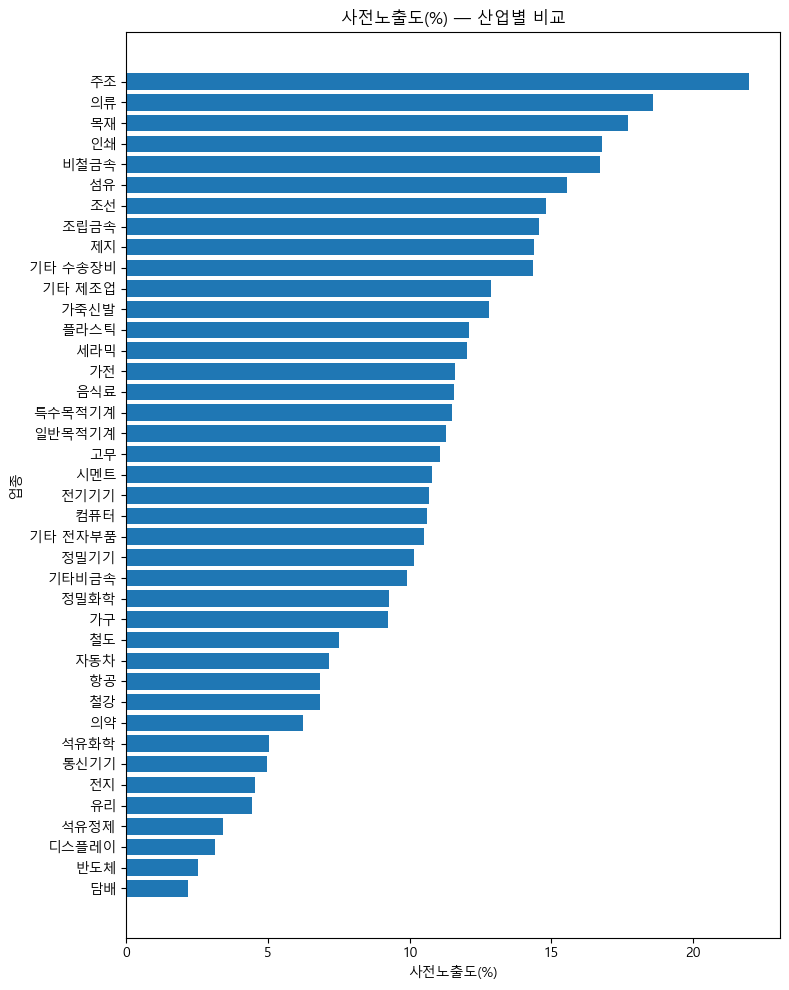

[사전노출도(%)] 상위 10개


,업종코드,업종,사전노출도(%),사전현금여력(%)
135,I3310,주조,21.9698,98.6350
165,I3404,의류,18.5939,151.2672
175,I3406,목재,17.6988,86.1826
185,I3408,인쇄,16.7769,93.5258
130,I3309,비철금속,16.7155,146.5902
160,I3403,섬유,15.5451,123.4549
145,I3312,조선,14.7942,88.7963
140,I3311,조립금속,14.5744,122.5156
180,I3407,제지,14.3977,100.8279
85,I3209,기타 수송장비,14.3598,101.6624


[사전노출도(%)] 하위 10개


,업종코드,업종,사전노출도(%),사전현금여력(%)
155,I3402,담배,2.1656,201.0193
5,I3102,반도체,2.5248,167.5219
10,I3103,디스플레이,3.1274,183.0156
90,I3301,석유정제,3.4069,149.6326
105,I3304,유리,4.4231,137.0672
35,I3108,전지,4.5279,157.0878
20,I3105,통신기기,4.9656,167.2930
45,I3201,석유화학,5.0316,156.9266
0,I3101,의약,6.2302,175.6402
125,I3308,철강,6.8284,141.0925


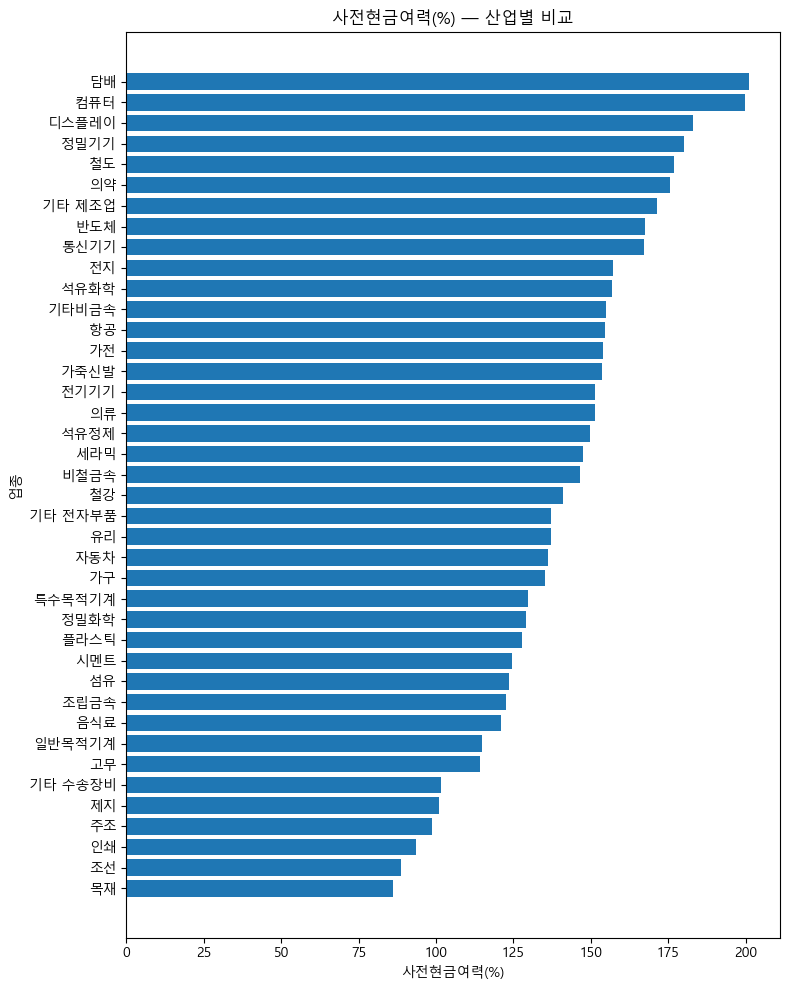

[사전현금여력(%)] 상위 10개


,업종코드,업종,사전노출도(%),사전현금여력(%)
155,I3402,담배,2.1656,201.0193
15,I3104,컴퓨터,10.5978,199.8889
10,I3103,디스플레이,3.1274,183.0156
30,I3107,정밀기기,10.1670,180.1077
80,I3208,철도,7.4932,176.8551
0,I3101,의약,6.2302,175.6402
195,I3410,기타 제조업,12.8665,171.2581
5,I3102,반도체,2.5248,167.5219
20,I3105,통신기기,4.9656,167.2930
35,I3108,전지,4.5279,157.0878


[사전현금여력(%)] 하위 10개


,업종코드,업종,사전노출도(%),사전현금여력(%)
175,I3406,목재,17.6988,86.1826
145,I3312,조선,14.7942,88.7963
185,I3408,인쇄,16.7769,93.5258
135,I3310,주조,21.9698,98.6350
180,I3407,제지,14.3977,100.8279
85,I3209,기타 수송장비,14.3598,101.6624
95,I3302,고무,11.0577,114.2498
65,I3205,일반목적기계,11.2875,114.8098
150,I3401,음식료,11.5648,120.8562
140,I3311,조립금속,14.5744,122.5156


In [24]:

pre_ind = merged[["업종코드","업종","사전노출도(%)","사전현금여력(%)"]].drop_duplicates()

for v in ["사전노출도(%)","사전현금여력(%)"]:
    tmp = pre_ind.sort_values(v)

    plt.figure(figsize=(8,10))
    plt.barh(tmp["업종"], tmp[v])
    plt.title(f"{v} — 산업별 비교")
    plt.xlabel(v)
    plt.ylabel("업종")
    plt.tight_layout()
    plt.show()

    print(f"[{v}] 상위 10개")
    display(tmp.sort_values(v, ascending=False).head(10))
    print(f"[{v}] 하위 10개")
    display(tmp.head(10))


### 사전노출도와 사전현금여력

사전노출도와 사전현금여력을 함께 비교하면 산업별 재무구조가 단순히 차입 규모 하나로만 설명되지 않으며, **단기성 차입에 대한 노출 정도와 이를 감당할 수 있는 유동성 여력이 서로 다른 차원으로 나타남**을 확인할 수 있다.

특히 주조(사전노출도 21.97%, 사전현금여력 98.64%), 목재(17.70%, 86.18%), 인쇄(16.78%, 93.53%), 조선(14.79%, 88.80%) 등은 상대적으로 높은 단기차입 노출도와 낮은 유동성 여력이 동시에 나타났다. 이러한 산업은 외부 충격이 발생했을 때 자금조달 부담에 상대적으로 더 민감하게 반응할 가능성을 검토할 필요가 있다.

반대로 담배(2.17%, 201.02%), 반도체(2.52%, 167.52%), 디스플레이(3.13%, 183.02%), 통신기기(4.97%, 167.29%) 등은 사전노출도가 낮으면서 유동성 여력이 상대적으로 높은 모습을 보였다.

따라서 분석대상 산업 사이에는 **충격 발생 이전의 재무적 취약성에 상당한 이질성**이 존재한다. 이는 이후 원자재 가격충격의 영향이 모든 산업에서 동일하게 나타날 것이라고 가정하기보다, 사전 차입노출도와 유동성 여력에 따라 충격의 효과가 달라지는지를 검토할 필요가 있음을 보여준다.

다만 사전현금여력은 실제 현금보유액 자체가 아니라 `유동자산 / 유동부채`에 기반한 유동성 지표이므로, 이후 해석에서는 ICR 등 다른 재무지표와 함께 확인한다.


# 9. 최종 판정

병합 오류와 원자료 자체 특이값을 분리해서 판단한다.

- 키가 정확히 대응하는가
- 직접 병합값이 원자료와 같은가
- 파생변수가 다시 계산해도 같은가
- 특이값이 원자료에도 같은가

를 모두 종합한다.


In [25]:

all_direct_ok = bad_direct.empty
flag_merge_mismatch = int(flag_summary["그중 원자료 불일치"].sum())

result = pd.DataFrame([
    ["키 구조", all_key_ok, "원자료 3개와 업종코드×연도 1:1 대응"],
    ["직접 병합값", all_direct_ok, "안정성·수익성·원자재 값 직접 대조"],
    ["파생변수", all_derived_ok, "사전노출도·사전현금여력·Post·상호작용항 재계산"],
    ["전체 재구성", all_full_ok, "원자료에서 16개 열 전체 재생성"],
    ["특이점 원자료 대조", flag_merge_mismatch == 0,
     f"특이점 중 병합과정 불일치 {flag_merge_mismatch}건"]
], columns=["검사","통과","해석"])

display(result)

if result["통과"].all():
    msg = (
        "## ✅ 병합 검증 결론\n\n"
        "**현재 `평시_재무_원자재_병합패널.csv`는 원자료 기준으로 정상적으로 병합된 것으로 확인됩니다.**\n\n"
        "- 분석기간의 모든 산업×연도 키가 원자료와 대응\n"
        "- 직접 병합된 값이 원자료와 동일\n"
        "- 파생변수도 원자료에서 동일하게 재현\n"
        "- 그래프에서 튀는 값은 존재하지만, 확인된 특이값은 원자료에도 동일하게 존재하므로 병합 때문에 생긴 값은 아님\n\n"
        "### 별도 확인\n"
        f"`Post`는 현재 파일에서 **{cutoff}년부터 1**입니다. "
        "이 규칙은 파일 내부적으로 일관되지만, 연구설계상 그 연도가 의도한 기준인지 여부는 별도로 확인해야 합니다."
    )
else:
    msg = "## ⚠️ 일부 병합 검증이 통과하지 않았습니다. 위 검사표를 확인하세요."

display(Markdown(msg))


,검사,통과,해석
0,키 구조,True,원자료 3개와 업종코드×연도 1:1 대응
1,직접 병합값,True,안정성·수익성·원자재 값 직접 대조
2,파생변수,True,사전노출도·사전현금여력·Post·상호작용항 재계산
3,전체 재구성,True,원자료에서 16개 열 전체 재생성
4,특이점 원자료 대조,True,특이점 중 병합과정 불일치 0건


## ✅ 병합 검증 결론

**현재 `평시_재무_원자재_병합패널.csv`는 원자료 기준으로 정상적으로 병합된 것으로 확인됩니다.**

- 분석기간의 모든 산업×연도 키가 원자료와 대응
- 직접 병합된 값이 원자료와 동일
- 파생변수도 원자료에서 동일하게 재현
- 그래프에서 튀는 값은 존재하지만, 확인된 특이값은 원자료에도 동일하게 존재하므로 병합 때문에 생긴 값은 아님

### 별도 확인
`Post`는 현재 파일에서 **2018년부터 1**입니다. 이 규칙은 파일 내부적으로 일관되지만, 연구설계상 그 연도가 의도한 기준인지 여부는 별도로 확인해야 합니다.